In [ ]:
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from scipy.stats import median_abs_deviation
import numpy as np

# Accept argument liver or immune
if len(sys.argv) != 2 or sys.argv[1] not in ["liver", "immune"]:
    print("Usage: python generate_embedding_script.py [liver|immune]")
    sys.exit(1)

# Read in the argument
analysis_type = sys.argv[1]

model_dir = Path("/mnt/hd1/home/ankitray/scFM/scGPT_CP")

# Set Base directory to the location of this script
BASE = Path('/mnt/hd1/home/ankitray/scFM/')

# If liver set the liver data directory, cell type key as liver and out path as liver
if analysis_type == "liver":
    cell_type_key = "typist_liver_majority_voting"
    out_path = Path('/mnt/hd1/home/ankitray/scFM/data/liver_cell_type_adata_embedded/')
    data_dir = BASE / 'data/liver_cell_type_adata'
    OUTPUT_DIR      = '/mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_liver'
    CELL_TYPE_COL   = 'typist_liver_majority_voting'
elif analysis_type == "immune":
    cell_type_key = "typist_immune_majority_voting"
    out_path = Path('/mnt/hd1/home/ankitray/scFM/data/immune_cell_type_adata_embedded/')
    data_dir = BASE / 'data/immune_cell_type_adata'
    OUTPUT_DIR      = '/mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_liver'
    CELL_TYPE_COL   = 'typist_liver_majority_voting'

## Immune Setup

In [1]:
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from scipy.stats import median_abs_deviation
import numpy as np

# Set Base directory to the grandparent location of this script
BASE = Path('/mnt/hd1/home/ankitray/scFM/')

# Set working directory to the location of this script 
data_dir = BASE / 'data/immune_cell_type_adata_embedded/'


/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Read in each h5ad file with the Anndata object variable name being it's file name without the extension and store in dictionary
adata_dict = {}

for h5ad_file in data_dir.glob('*.h5ad'):
    adata_name = h5ad_file.stem  # Get file name without extension
    print(adata_name)
    adata_dict[adata_name] = ad.read_h5ad(h5ad_file)  # Read h5ad file and store in dictionary



Memory B cells_embedded
NK cells_embedded
Naive B cells_embedded
Tem-Trm cytotoxic T cells_embedded
MAIT cells_embedded
CD16+ NK cells_embedded
CRTAM+ gamma-delta T cells_embedded
Endothelial cells_embedded
pDC_embedded
Non-classical monocytes_embedded
Classical monocytes_embedded
Kupffer cells_embedded
CD16- NK cells_embedded
Tem-Temra cytotoxic T cells_embedded
Tcm-Naive helper T cells_embedded
Tem-Effector helper T cells_embedded


Configuration

In [5]:
import os
import numpy as np
import pandas as pd

# ── User config ────────────────────────────────────────────────────────────────
CELL_TYPE_COL   = 'typist_immune_majority_voting'
CONDITION_COL   = 'broad_condition'
CONTROL_LABEL   = 'Healthy'
TARGET_LABEL    = 'MASH'
DONOR_COL       = 'patient_id'
EMBEDDING_KEY   = 'X_scGPT'          # adata.obsm key
MIN_CELLS_PER_STATE = 30
FOCUS_CELLTYPES = []                  # leave empty to test all cell types
ALT_STATES      = []                  # no alt states
OUTPUT_DIR      = '/mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_immune'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Building Embeddings DF

In [7]:
embeddings_dict = {}

for name, adata_item in adata_dict.items():
    emb_matrix = adata_item.obsm[EMBEDDING_KEY]
    n_dims = emb_matrix.shape[1]
    emb_cols = [f'emb_{i}' for i in range(n_dims)]

    embeddings = pd.DataFrame(
        emb_matrix,
        index=adata_item.obs_names,
        columns=emb_cols
    )
    embeddings['cell_type'] = adata_item.obs[CELL_TYPE_COL].values
    embeddings['condition'] = adata_item.obs[CONDITION_COL].values
    embeddings['donor'] = adata_item.obs[DONOR_COL].values
    embeddings['cell_id'] = adata_item.obs_names

    mask = embeddings['condition'].isin([CONTROL_LABEL, TARGET_LABEL])
    embeddings = embeddings[mask].copy()
    #embeddings = embeddings.dropna(subset=['cell_type', 'condition', 'donor'])

    embeddings_dict[name] = embeddings
    print(f"{name}: {embeddings_dict[name].shape}")
    #Print embeddings condions and donors
    print(embeddings_dict[name]['condition'].value_counts())
    #print(embeddings['donor'].value_counts())

Memory B cells_embedded: (699, 516)
condition
MASH       387
Healthy    312
MASLD        0
Name: count, dtype: int64
NK cells_embedded: (1926, 516)
condition
MASH       1799
Healthy     127
MASLD         0
Name: count, dtype: int64
Naive B cells_embedded: (2515, 516)
condition
MASH       1382
Healthy    1133
MASLD         0
Name: count, dtype: int64
Tem-Trm cytotoxic T cells_embedded: (8324, 516)
condition
MASH       5269
Healthy    3055
MASLD         0
Name: count, dtype: int64
MAIT cells_embedded: (7473, 516)
condition
Healthy    4234
MASH       3239
MASLD         0
Name: count, dtype: int64
CD16+ NK cells_embedded: (11190, 516)
condition
MASH       6533
Healthy    4657
MASLD         0
Name: count, dtype: int64
CRTAM+ gamma-delta T cells_embedded: (1019, 516)
condition
MASH       839
Healthy    180
Name: count, dtype: int64
Endothelial cells_embedded: (297, 516)
condition
Healthy    297
MASLD        0
Name: count, dtype: int64
pDC_embedded: (388, 516)
condition
MASH       274
Healthy

Testing parameters and cleaning cell type names

In [8]:
emb_feature_cols_dict = {}
cell_types_to_test_dict = {}
donor_col_in_emb_dict = {}

for name, embeddings in embeddings_dict.items():
    embeddings['cell_type'] = embeddings['cell_type'].str.replace('/', '_', regex=False)

    focus_celltypes = [ct.replace('/', '_') for ct in FOCUS_CELLTYPES] if FOCUS_CELLTYPES else []
    emb_meta_cols = {'cell_type', 'condition', 'cell_id', 'donor'}
    emb_feature_cols = [
        c for c in embeddings.columns
        if c not in emb_meta_cols
        and pd.api.types.is_numeric_dtype(embeddings[c])
    ]

    cell_types_to_test = focus_celltypes if focus_celltypes else embeddings['cell_type'].unique().tolist()
    cell_types_to_test = [ct for ct in cell_types_to_test if ct in embeddings['cell_type'].values]

    actual_donor_col = None
    for _dc in ['donor', 'Donor', 'donor_id', 'patient_id', 'sample_id']:
        if _dc in embeddings.columns:
            actual_donor_col = _dc
            break

    emb_feature_cols_dict[name] = emb_feature_cols
    cell_types_to_test_dict[name] = cell_types_to_test
    donor_col_in_emb_dict[name] = actual_donor_col

    print(f'Dataset: {name}')
    print(f'  Using donor column: "{actual_donor_col}"')
    print(f'  State comparisons: {[f"{CONTROL_LABEL} vs {TARGET_LABEL}"]}')
    print(f'  Cell types to test ({len(cell_types_to_test)}): {cell_types_to_test}')
    print(f'  Embedding feature columns: {len(emb_feature_cols)}')

Dataset: Memory B cells_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['Memory B cells']
  Embedding feature columns: 512
Dataset: NK cells_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['NK cells']
  Embedding feature columns: 512
Dataset: Naive B cells_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['Naive B cells']
  Embedding feature columns: 512
Dataset: Tem-Trm cytotoxic T cells_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['Tem_Trm cytotoxic T cells']
  Embedding feature columns: 512
Dataset: MAIT cells_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['MAIT cells']
  Embedding feature columns: 512
Dataset: CD16+ NK cells_embedded
  Using donor column: "donor"
  State comparisons: ['Heal

In [9]:
# Additional Imports
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
#warnings.filterwarnings('ignore')

Seperation Test Function

In [10]:
def run_separation_test_publishable(
        embeddings_df, cell_type, control_label, target_label,
        emb_cols=None, donor_col='donor'):
    """
    Separation test with patient-aware statistics for publication.

    Computes:
    - Per-cell cosine similarity margin (Liu et al. Step 6)
    - Mann-Whitney U test (two-tailed composite p-value)
    - Patient-level Cohen's d (guards against pseudoreplication)
    - Balanced accuracy from cross-validated logistic classifier

    Returns dict with: passes, p_value, sep_score, cohens_d,
    balanced_accuracy, n_ctrl, n_tgt, n_donors_ctrl, n_donors_tgt,
    ctrl_margins, tgt_margins.
    """
    ct_mask   = embeddings_df['cell_type'] == cell_type
    ctrl_mask = ct_mask & (embeddings_df['condition'] == control_label)
    tgt_mask  = ct_mask & (embeddings_df['condition'] == target_label)
    n_ctrl, n_tgt = ctrl_mask.sum(), tgt_mask.sum()

    empty = {'passes': False, 'p_value': 1.0, 'sep_score': 0.0,
             'cohens_d': None, 'balanced_accuracy': 0.5,
             'n_ctrl': n_ctrl, 'n_tgt': n_tgt,
             'n_donors_ctrl': 0, 'n_donors_tgt': 0,
             'ctrl_margins': np.array([]), 'tgt_margins': np.array([])}

    if n_ctrl < MIN_CELLS_PER_STATE or n_tgt < MIN_CELLS_PER_STATE:
        print(f'   {cell_type} [{control_label} vs {target_label}]: '
              f'insufficient cells (ctrl={n_ctrl}, tgt={n_tgt}). Skipping.')
        return empty

    if emb_cols is None:
        meta = {'cell_type', 'condition', 'donor', 'cell_id', 'index'}
        emb_cols = [c for c in embeddings_df.columns
                    if c not in meta
                    and pd.api.types.is_numeric_dtype(embeddings_df[c])]

    ctrl_embs = embeddings_df.loc[ctrl_mask, emb_cols].values.astype(np.float32)
    tgt_embs  = embeddings_df.loc[tgt_mask,  emb_cols].values.astype(np.float32)
    ctrl_centroid = ctrl_embs.mean(axis=0, keepdims=True)
    tgt_centroid  = tgt_embs.mean(axis=0,  keepdims=True)

    ctrl_margins = (cosine_similarity(ctrl_embs, ctrl_centroid).flatten() -
                    cosine_similarity(ctrl_embs, tgt_centroid).flatten())
    tgt_margins  = (cosine_similarity(tgt_embs,  tgt_centroid).flatten() -
                    cosine_similarity(tgt_embs,  ctrl_centroid).flatten())

    _, p_ctrl = mannwhitneyu(ctrl_margins, np.zeros(len(ctrl_margins)),
                              alternative='greater')
    _, p_tgt  = mannwhitneyu(tgt_margins,  np.zeros(len(tgt_margins)),
                              alternative='greater')
    sep_score  = (ctrl_margins.mean() + tgt_margins.mean()) / 2
    p_combined = max(p_ctrl, p_tgt)

    # Patient-level Cohen's d
    n_donors_ctrl = n_donors_tgt = 0
    cohens_d = None
    actual_donor_col = None
    for dc in ([donor_col] if donor_col else []) + ['donor', 'Donor', 'patient_id']:
        if dc and dc in embeddings_df.columns:
            actual_donor_col = dc
            break

    if actual_donor_col:
        ctrl_donors = embeddings_df.loc[ctrl_mask, actual_donor_col].values
        tgt_donors  = embeddings_df.loc[tgt_mask,  actual_donor_col].values
        n_donors_ctrl = len(np.unique(ctrl_donors))
        n_donors_tgt  = len(np.unique(tgt_donors))
        ctrl_donor_means = (
            pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
        )
        tgt_donor_means  = (
            pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()
        )
        if len(ctrl_donor_means) >= 2 and len(tgt_donor_means) >= 2:
            pooled_sd = np.sqrt(
                (ctrl_donor_means.std()**2 + tgt_donor_means.std()**2) / 2 + 1e-10
            )
            cohens_d = float(
                (tgt_donor_means.mean() - ctrl_donor_means.mean()) / pooled_sd
            )

    # Balanced accuracy (linear classifier, 3-fold CV)
    X_all = np.vstack([ctrl_embs, tgt_embs])
    y_all = np.array([0]*len(ctrl_embs) + [1]*len(tgt_embs))
    ba_scores = []
    n_splits  = min(3, min(n_ctrl, n_tgt) // 10)
    if n_splits >= 2:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        for train_idx, test_idx in skf.split(X_all, y_all):
            clf = LogisticRegression(max_iter=500, C=0.1, random_state=42,
                                      solver='lbfgs')
            clf.fit(X_all[train_idx], y_all[train_idx])
            ba_scores.append(balanced_accuracy_score(
                y_all[test_idx], clf.predict(X_all[test_idx])
            ))
    balanced_accuracy = float(np.mean(ba_scores)) if ba_scores else 0.5

    passes = (p_combined < 0.05) and (sep_score > 0)

    return {
        'passes':             passes,
        'p_value':            float(p_combined),
        'sep_score':          float(sep_score),
        'cohens_d':           cohens_d,
        'balanced_accuracy':  balanced_accuracy,
        'n_ctrl':             int(n_ctrl),
        'n_tgt':              int(n_tgt),
        'n_donors_ctrl':      int(n_donors_ctrl),
        'n_donors_tgt':       int(n_donors_tgt),
        'ctrl_margins':       ctrl_margins,
        'tgt_margins':        tgt_margins,
    }



Run Seperation Test

In [11]:
# Define state pairs for comparison
state_pairs = [
    (CONTROL_LABEL, TARGET_LABEL, f"{CONTROL_LABEL} vs {TARGET_LABEL}")
]

print(f"State pairs to test: {state_pairs}")

State pairs to test: [('Healthy', 'MASH', 'Healthy vs MASH')]


In [12]:
# ── Run all separation tests (adapted for embeddings_dict) ────────────────────
separation_results = {}
all_sep_rows = []

print('\nRunning separation tests (dict format)...')

for emb_name, embeddings in embeddings_dict.items():
    # get cell types for this embeddings DataFrame (usually a single-item list)
    cts = cell_types_to_test_dict.get(emb_name, [])
    if not cts:
        continue

    emb_cols = emb_feature_cols_dict.get(emb_name, emb_feature_cols)
    donor_col = donor_col_in_emb_dict.get(emb_name, DONOR_COL)

    for ct in cts:
        separation_results.setdefault(ct, {})
        for label_a, label_b, comp_name in state_pairs:

            has_a = ((embeddings['cell_type'] == ct) &
                     (embeddings['condition'] == label_a)).sum() >= MIN_CELLS_PER_STATE
            has_b = ((embeddings['cell_type'] == ct) &
                     (embeddings['condition'] == label_b)).sum() >= MIN_CELLS_PER_STATE

            if not has_a or not has_b:
                print(f"   {ct} [{comp_name}] ({emb_name}): missing condition data — skipping.")
                separation_results[ct][comp_name] = {
                    'passes': False, 'p_value': 1.0, 'sep_score': 0.0,
                    'cohens_d': None, 'balanced_accuracy': 0.5,
                    'n_ctrl': 0, 'n_tgt': 0,
                    'n_donors_ctrl': 0, 'n_donors_tgt': 0,
                    'ctrl_margins': np.array([]), 'tgt_margins': np.array([])
                }
                continue

            res = run_separation_test_publishable(
                embeddings, ct, label_a, label_b,
                emb_cols=emb_cols,
                donor_col=donor_col
            )
            separation_results[ct][comp_name] = res

            all_sep_rows.append({
                'cell_type':         ct,
                'dataset':           emb_name,
                'comparison':        comp_name,
                'label_a':           label_a,
                'label_b':           label_b,
                'passes':            res['passes'],
                'sep_score':         round(res['sep_score'], 5),
                'p_value':           res['p_value'],
                'cohens_d':          round(res['cohens_d'], 3)
                                     if res['cohens_d'] is not None else None,
                'balanced_accuracy': round(res['balanced_accuracy'], 3),
                'n_a':               res['n_ctrl'],
                'n_b':               res['n_tgt'],
                'n_donors_a':        res['n_donors_ctrl'],
                'n_donors_b':        res['n_donors_tgt'],
            })

            d_str  = f"{res['cohens_d']:.3f}" if res['cohens_d'] is not None else 'N/A'
            status = 'PASS' if res['passes'] else 'FAIL'
            print(f"   {ct} [{comp_name}] ({emb_name}): {status}  "
                  f"sep={res['sep_score']:.4f}  p={res['p_value']:.2e}  "
                  f"d={d_str}  bal_acc={res['balanced_accuracy']:.3f}  "
                  f"n=({res['n_ctrl']},{res['n_tgt']})")



Running separation tests (dict format)...


/tmp/ipykernel_814897/2107000701.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_814897/2107000701.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   Memory B cells [Healthy vs MASH] (Memory B cells_embedded): PASS  sep=0.0020  p=7.69e-06  d=-0.253  bal_acc=0.500  n=(312,387)


/tmp/ipykernel_814897/2107000701.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_814897/2107000701.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   NK cells [Healthy vs MASH] (NK cells_embedded): PASS  sep=0.0251  p=2.44e-02  d=-1.027  bal_acc=0.500  n=(127,1799)


...

   Tem_Temra cytotoxic T cells [Healthy vs MASH] (Tem-Temra cytotoxic T cells_embedded): PASS  sep=0.0012  p=6.50e-53  d=-0.121  bal_acc=0.652  n=(1883,2004)


/tmp/ipykernel_814897/2107000701.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_814897/2107000701.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   Tcm_Naive helper T cells [Healthy vs MASH] (Tcm-Naive helper T cells_embedded): PASS  sep=0.0190  p=4.00e-18  d=-0.321  bal_acc=0.500  n=(452,1071)


/tmp/ipykernel_814897/2107000701.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_814897/2107000701.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   Tem_Effector helper T cells [Healthy vs MASH] (Tem-Effector helper T cells_embedded): PASS  sep=0.0012  p=1.80e-25  d=-0.103  bal_acc=0.501  n=(1803,2682)


Find passing cell types and output summary csv

In [13]:
# Since there's only one comparison, passing = passes that comparison
primary_comp = f"{CONTROL_LABEL} vs {TARGET_LABEL}"

passing_celltypes = [
    ct for ct in separation_results.keys()
    if separation_results[ct].get(primary_comp, {}).get('passes', False)
    and separation_results[ct][primary_comp]['n_ctrl'] > 0
    and separation_results[ct][primary_comp]['n_tgt'] > 0
]

print(f'\n{len(passing_celltypes)}/{len(separation_results)} cell types pass.')
print(f'   Passing: {passing_celltypes}')

# Save summary
sep_summary = pd.DataFrame(all_sep_rows)
sep_summary_path = os.path.join(OUTPUT_DIR, 'separation_test_summary.csv')
sep_summary.to_csv(sep_summary_path, index=False)
print(f'\nSaved summary to: {sep_summary_path}')
display(sep_summary[['cell_type', 'comparison', 'passes', 'sep_score',
                      'p_value', 'cohens_d', 'balanced_accuracy',
                      'n_a', 'n_b']].sort_values('sep_score', ascending=False))



14/16 cell types pass.
   Passing: ['Memory B cells', 'NK cells', 'Naive B cells', 'Tem_Trm cytotoxic T cells', 'MAIT cells', 'CD16+ NK cells', 'CRTAM+ gamma-delta T cells', 'pDC', 'Non-classical monocytes', 'Classical monocytes', 'CD16- NK cells', 'Tem_Temra cytotoxic T cells', 'Tcm_Naive helper T cells', 'Tem_Effector helper T cells']

Saved summary to: /mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_immune/separation_test_summary.csv


,cell_type,comparison,passes,sep_score,p_value,cohens_d,balanced_accuracy,n_a,n_b
1,NK cells,Healthy vs MASH,True,0.02510,2.440189e-02,-1.027,0.500,127,1799
12,Tcm_Naive helper T cells,Healthy vs MASH,True,0.01896,3.997087e-18,-0.321,0.500,452,1071
2,Naive B cells,Healthy vs MASH,True,0.00525,1.234522e-104,-0.112,0.700,1133,1382
9,Classical monocytes,Healthy vs MASH,True,0.00319,6.259294e-40,0.327,0.500,688,488
7,pDC,Healthy vs MASH,True,0.00302,2.493023e-09,-0.019,0.500,114,274
4,MAIT cells,Healthy vs MASH,True,0.00296,4.028668e-157,0.158,0.671,4234,3239
8,Non-classical monocytes,Healthy vs MASH,True,0.00295,4.584929e-12,0.017,0.537,809,613
6,CRTAM+ gamma-delta T cells,Healthy vs MASH,True,0.00273,8.903900e-19,0.165,0.500,180,839
5,CD16+ NK cells,Healthy vs MASH,True,0.00265,0.000000e+00,-0.715,0.654,4657,6533
10,CD16- NK cells,Healthy vs MASH,True,0.00218,0.000000e+00,-0.569,0.665,7389,9905


## Figures

Cell types in separation_results : 16
Cell types in ct_embedding_map   : 16
PCA fitted for 16 cell types.

Generating Figure 1: Per-cell-type separation panels...
   [Healthy vs MASH]: 14 cell types with PCA + stats


/tmp/ipykernel_814897/3797918190.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_814897/3797918190.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_814897/3797918190.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_814897/3797918190.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

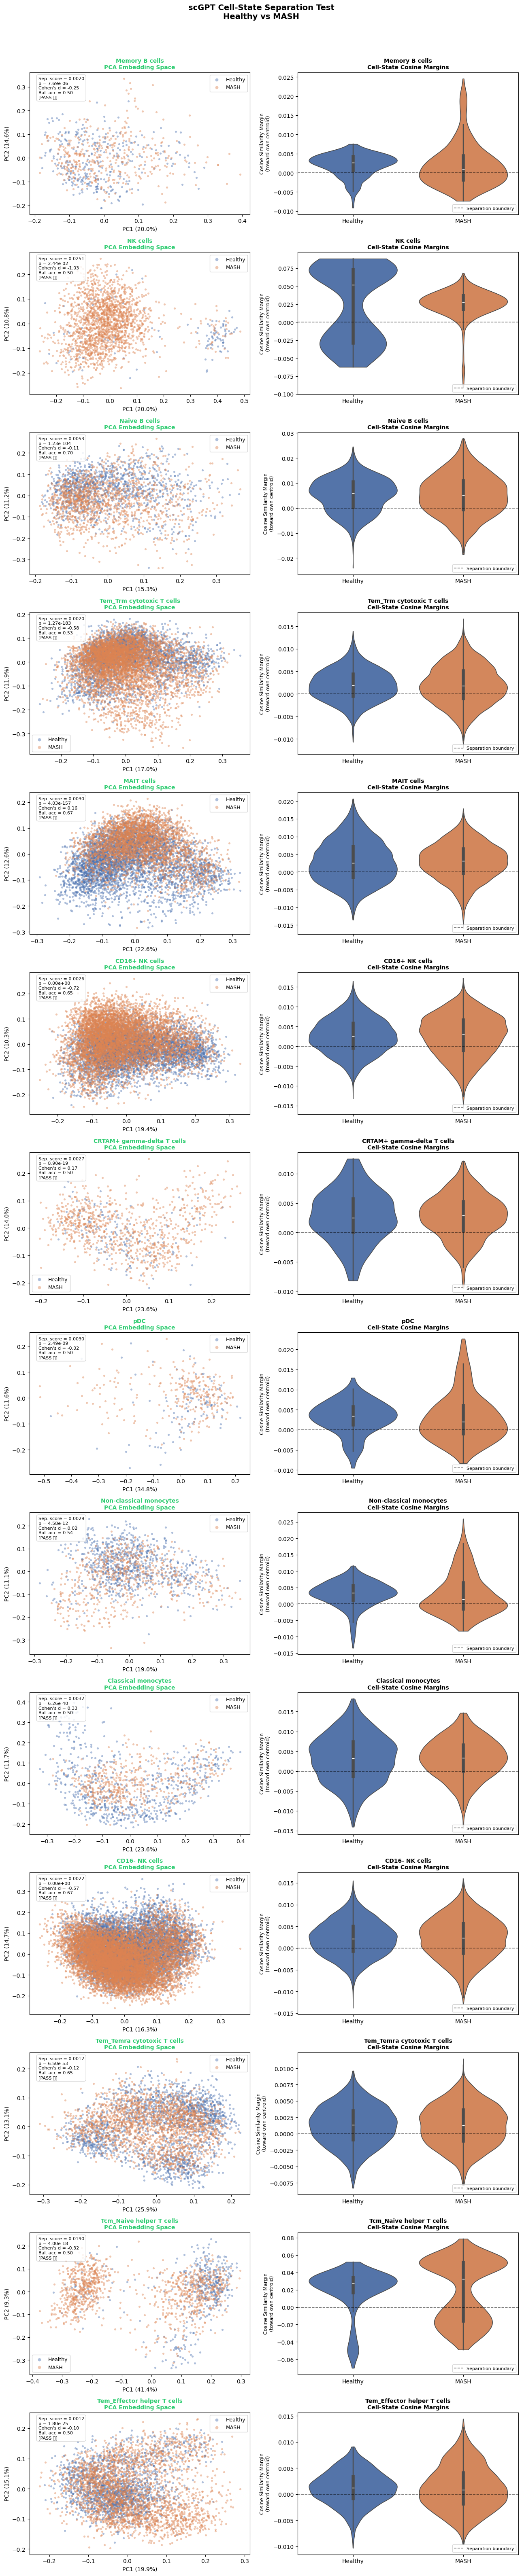

   Saved: /mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_immune/separation_test_figures/separation_per_celltype_Healthy_vs_MASH.pdf

Generating Figure 2: Multi-cell-type summary bar charts...


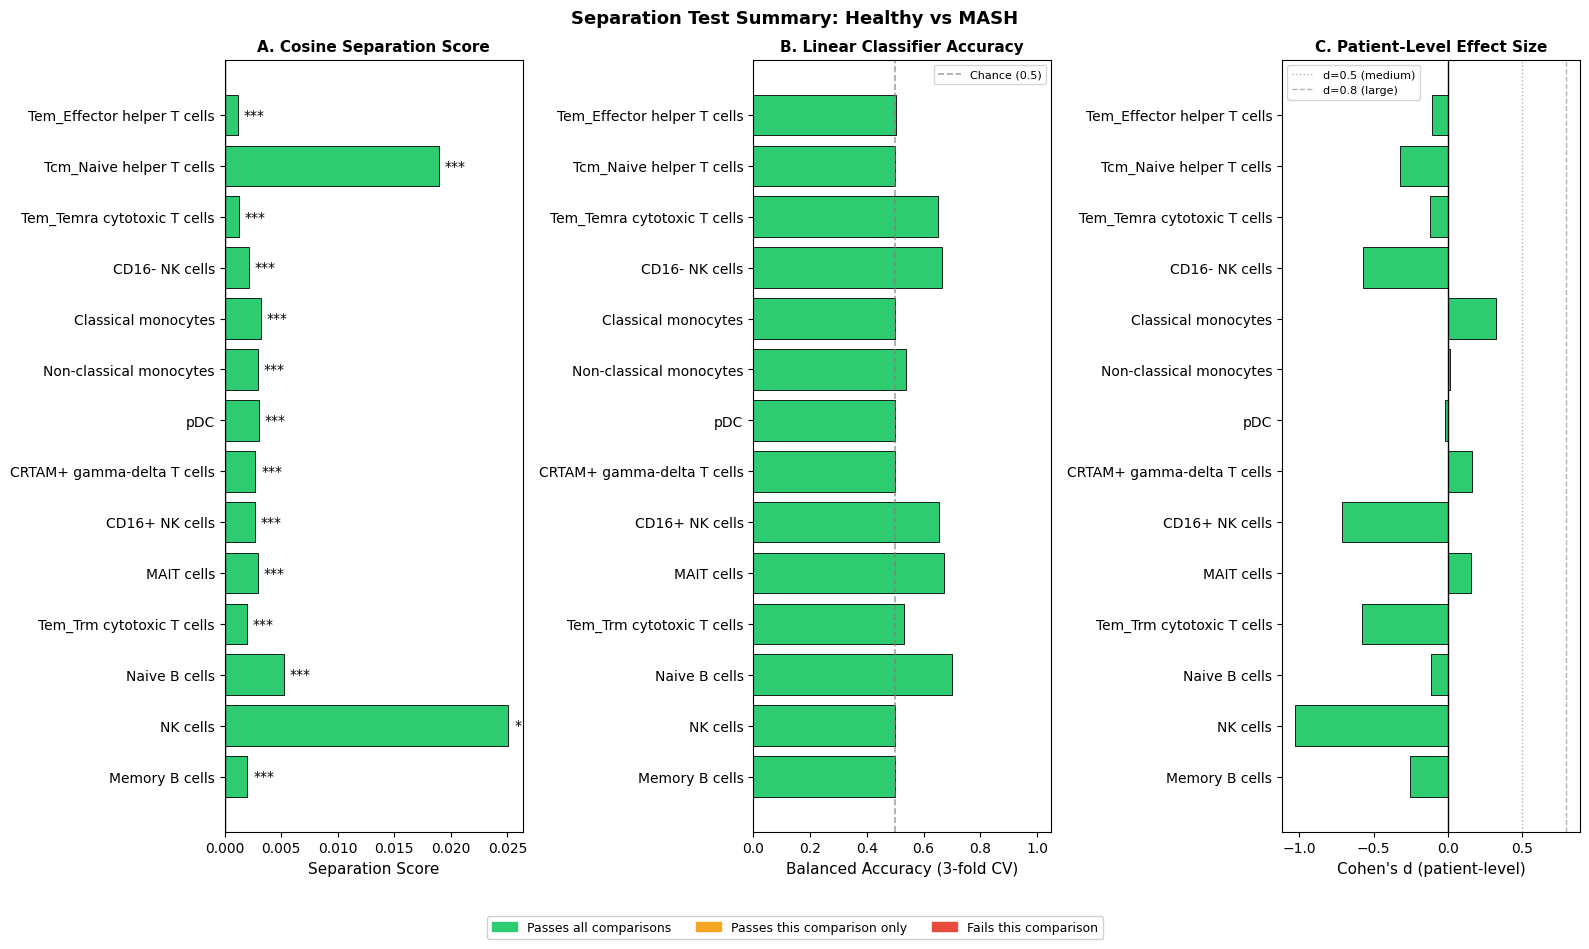

   Saved: /mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_immune/separation_test_figures/separation_summary_Healthy_vs_MASH.pdf

Done. All figures saved to: /mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_immune/separation_test_figures


In [14]:
"""
Fixed Figure Generation (v2)
=============================
Drop this cell in place of the original "Figures" cell.

Root cause of the original bug
--------------------------------
The figure cell used bare loop variables `embeddings`, `emb_feature_cols`,
and `cell_types_to_test` — all left pointing to the *last* dataset after the
separation-test loop, so only that dataset's cell types produced plots.

v1 fix issue
-------------
v1 concatenated all datasets and fit one global PCA. But embeddings are
generated *per cell type*, so a global PCA is dominated by between-cell-type
variance rather than within-cell-type condition variance — making the scatter
plots misleading.

v2 fix
-------
Fit a *separate* PCA per cell type using only that cell type's embedding rows,
then use those per-cell-type coordinates for plotting. Stats (sep_score,
p_value, cohens_d, margins) come from separation_results as before — those
are already correct across all cell types.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA

# ── Output directory ──────────────────────────────────────────────────────────
SEP_FIG_DIR = os.path.join(OUTPUT_DIR, 'separation_test_figures')
os.makedirs(SEP_FIG_DIR, exist_ok=True)

SIG_GREEN = '#2ecc71'
FAIL_RED  = '#e74c3c'
AMBER     = '#F5A623'

_alt_states  = ALT_STATES if 'ALT_STATES' in dir() and ALT_STATES else []
_all_states  = [CONTROL_LABEL, TARGET_LABEL] + list(_alt_states)
_base_colors = ['#4C72B0', '#DD8452', '#59A14F', '#B07AA1',
                '#E15759', '#76B7B2', '#F28E2B']
PALETTE = {state: _base_colors[i % len(_base_colors)]
           for i, state in enumerate(_all_states)}

_tested_pairs = list(state_pairs)

# ── Meta columns to exclude from feature detection ────────────────────────────
_meta_cols = {'cell_type', 'condition', 'donor', 'cell_id'}

# ─────────────────────────────────────────────────────────────────────────────
# Build a unified lookup:
#   ct_embedding_map[cell_type] = (embeddings_df_for_that_ct, feature_cols)
#
# Each entry in embeddings_dict is one per-cell-type DataFrame. A cell type
# appears in exactly one of them (keyed by the AnnData filename stem).
# We invert the mapping so figure code can look up by cell_type string.
# ─────────────────────────────────────────────────────────────────────────────
ct_embedding_map = {}   # cell_type str → (DataFrame, feature_col_list)

for emb_name, df in embeddings_dict.items():
    feat_cols = [
        c for c in df.columns
        if c not in _meta_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    for ct in df['cell_type'].unique():
        ct_embedding_map[ct] = (df, feat_cols)

all_cell_types_tested = list(separation_results.keys())
print(f"Cell types in separation_results : {len(all_cell_types_tested)}")
print(f"Cell types in ct_embedding_map   : {len(ct_embedding_map)}")

# ─────────────────────────────────────────────────────────────────────────────
# FIT PER-CELL-TYPE PCA
# For each cell type fit PCA on its own embedding rows only, then store the
# 2D coordinates alongside condition labels for plotting.
# ─────────────────────────────────────────────────────────────────────────────
ct_pca_map = {}   # cell_type → {'df': DataFrame with PC1/PC2, 'pca': PCA obj}

for ct in all_cell_types_tested:
    if ct not in ct_embedding_map:
        continue
    df, feat_cols = ct_embedding_map[ct]

    ct_df = df[df['cell_type'] == ct].copy()
    if len(ct_df) < 2:
        continue

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(ct_df[feat_cols].values)
    ct_df['PC1'] = coords[:, 0]
    ct_df['PC2'] = coords[:, 1]

    ct_pca_map[ct] = {'df': ct_df, 'pca': pca}

print(f"PCA fitted for {len(ct_pca_map)} cell types.")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Per-cell-type panels — one figure per comparison
#   n_celltypes rows × 2 columns  (PCA scatter | cosine-margin violin)
# ══════════════════════════════════════════════════════════════════════════════
print("\nGenerating Figure 1: Per-cell-type separation panels...")

for label_a, label_b, comp_name in _tested_pairs:
    pair_palette = {label_a: PALETTE[label_a], label_b: PALETTE[label_b]}

    cts_with_data = [
        ct for ct in all_cell_types_tested
        if comp_name in separation_results.get(ct, {})
        and separation_results[ct][comp_name]['n_ctrl'] > 0
        and separation_results[ct][comp_name]['n_tgt']  > 0
        and ct in ct_pca_map
    ]

    if not cts_with_data:
        print(f"   No cell types with data for [{comp_name}] — skipping.")
        continue

    print(f"   [{comp_name}]: {len(cts_with_data)} cell types with PCA + stats")

    n_cts = len(cts_with_data)
    fig, axes = plt.subplots(n_cts, 2,
                              figsize=(13, 4.5 * n_cts),
                              squeeze=False)
    fig.suptitle(
        f'scGPT Cell-State Separation Test\n{comp_name}',
        fontsize=14, fontweight='bold', y=1.01
    )

    for row_idx, ct in enumerate(cts_with_data):
        res     = separation_results[ct][comp_name]
        pca_obj = ct_pca_map[ct]['pca']
        ct_df   = ct_pca_map[ct]['df']

        # Only plot the two conditions being compared
        plot_df = ct_df[ct_df['condition'].isin([label_a, label_b])]

        passes_all  = ct in passing_celltypes
        title_color = SIG_GREEN if passes_all else FAIL_RED

        # ── Panel A: PCA scatter ──────────────────────────────────────────
        ax = axes[row_idx, 0]
        for cond, color in pair_palette.items():
            m = plot_df['condition'] == cond
            ax.scatter(plot_df.loc[m, 'PC1'], plot_df.loc[m, 'PC2'],
                       c=color, alpha=0.45, s=14, linewidths=0,
                       label=cond, rasterized=True)
        ax.set_xlabel(
            f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
        ax.set_ylabel(
            f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
        ax.set_title(f'{ct}\nPCA Embedding Space',
                     fontsize=10, fontweight='bold', color=title_color)
        ax.legend(fontsize=9, markerscale=1.5, framealpha=0.8)

        d_str      = (f"Cohen's d = {res['cohens_d']:.2f}"
                      if res['cohens_d'] is not None else "Cohen's d = N/A")
        status_str = 'PASS ✅' if res['passes'] else 'FAIL ❌'
        ax.text(0.04, 0.97,
                f"Sep. score = {res['sep_score']:.4f}\n"
                f"p = {res['p_value']:.2e}\n"
                f"{d_str}\n"
                f"Bal. acc = {res['balanced_accuracy']:.2f}\n"
                f"[{status_str}]",
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round,pad=0.4', fc='white',
                          alpha=0.85, ec='#cccccc'))

        # ── Panel B: Cosine-margin violins ────────────────────────────────
        ax2 = axes[row_idx, 1]
        margin_parts = []
        if len(res['ctrl_margins']) > 0:
            margin_parts.append(pd.DataFrame({
                'Cosine Margin': res['ctrl_margins'],
                'Condition': label_a
            }))
        if len(res['tgt_margins']) > 0:
            margin_parts.append(pd.DataFrame({
                'Cosine Margin': res['tgt_margins'],
                'Condition': label_b
            }))
        if margin_parts:
            margin_df = pd.concat(margin_parts, ignore_index=True)
            sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
                           palette=pair_palette, ax=ax2, inner='box',
                           linewidth=1.2, cut=0, saturation=0.85)
            ax2.axhline(0, color='black', lw=1.2, ls='--', alpha=0.6,
                        label='Separation boundary')
            ax2.set_xlabel('', fontsize=10)
            ax2.set_ylabel(
                'Cosine Similarity Margin\n(toward own centroid)', fontsize=9)
            ax2.set_title(f'{ct}\nCell-State Cosine Margins',
                          fontsize=10, fontweight='bold')
            ax2.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    safe_comp = comp_name.replace(' ', '_').replace('/', '_')
    fig1_path = os.path.join(
        SEP_FIG_DIR, f'separation_per_celltype_{safe_comp}.pdf'
    )
    plt.savefig(fig1_path, dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig(fig1_path.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f"   Saved: {fig1_path}")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Multi-cell-type summary bar charts — one figure per comparison
#   3 panels: separation score | balanced accuracy | Cohen's d
# ══════════════════════════════════════════════════════════════════════════════
print("\nGenerating Figure 2: Multi-cell-type summary bar charts...")

def bar_color(ct, comp):
    if not separation_results[ct][comp]['passes']:
        return FAIL_RED
    if ct in passing_celltypes:
        return SIG_GREEN
    return AMBER

for label_a, label_b, comp_name in _tested_pairs:
    cts_for_comp = [
        ct for ct in all_cell_types_tested
        if comp_name in separation_results.get(ct, {})
        and separation_results[ct][comp_name]['n_ctrl'] > 0
        and separation_results[ct][comp_name]['n_tgt']  > 0
    ]

    if len(cts_for_comp) < 2:
        print(f"   Fewer than 2 cell types for [{comp_name}] — skipping.")
        continue

    sep_scores = [separation_results[ct][comp_name]['sep_score']   for ct in cts_for_comp]
    bal_accs   = [separation_results[ct][comp_name]['balanced_accuracy'] for ct in cts_for_comp]
    cohens_ds  = [(separation_results[ct][comp_name]['cohens_d'] or 0.0) for ct in cts_for_comp]
    pvals      = [separation_results[ct][comp_name]['p_value']     for ct in cts_for_comp]
    colors     = [bar_color(ct, comp_name) for ct in cts_for_comp]

    fig2, axes2 = plt.subplots(
        1, 3, figsize=(16, max(4, len(cts_for_comp) * 0.5 + 2))
    )
    fig2.suptitle(
        f'Separation Test Summary: {comp_name}',
        fontsize=13, fontweight='bold'
    )

    ax = axes2[0]
    bars = ax.barh(cts_for_comp, sep_scores, color=colors,
                   edgecolor='black', linewidth=0.6)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Separation Score', fontsize=11)
    ax.set_title('A. Cosine Separation Score', fontsize=11, fontweight='bold')
    max_sep = max(sep_scores) if sep_scores else 1
    for bar, pv in zip(bars, pvals):
        sig = ('***' if pv < 0.001 else '**' if pv < 0.01
               else '*' if pv < 0.05 else 'ns')
        ax.text(bar.get_width() + max_sep * 0.02,
                bar.get_y() + bar.get_height() / 2,
                sig, va='center', fontsize=10)

    ax2b = axes2[1]
    ax2b.barh(cts_for_comp, bal_accs, color=colors,
              edgecolor='black', linewidth=0.6)
    ax2b.axvline(0.5, color='gray', lw=1.2, ls='--', alpha=0.7, label='Chance (0.5)')
    ax2b.set_xlim(0, 1.05)
    ax2b.set_xlabel('Balanced Accuracy (3-fold CV)', fontsize=11)
    ax2b.set_title('B. Linear Classifier Accuracy', fontsize=11, fontweight='bold')
    ax2b.legend(fontsize=8)

    ax3 = axes2[2]
    ax3.barh(cts_for_comp, cohens_ds, color=colors,
             edgecolor='black', linewidth=0.6)
    ax3.axvline(0,   color='black', lw=1)
    ax3.axvline(0.5, color='gray', lw=1,   ls=':',  alpha=0.6, label="d=0.5 (medium)")
    ax3.axvline(0.8, color='gray', lw=1,   ls='--', alpha=0.6, label="d=0.8 (large)")
    ax3.set_xlabel("Cohen's d (patient-level)", fontsize=11)
    ax3.set_title("C. Patient-Level Effect Size", fontsize=11, fontweight='bold')
    ax3.legend(fontsize=8)

    legend_handles = [
        mpatches.Patch(color=SIG_GREEN, label='Passes all comparisons'),
        mpatches.Patch(color=AMBER,     label='Passes this comparison only'),
        mpatches.Patch(color=FAIL_RED,  label='Fails this comparison'),
    ]
    fig2.legend(handles=legend_handles, loc='lower center', ncol=3,
                fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    safe_comp = comp_name.replace(' ', '_').replace('/', '_')
    fig2_path = os.path.join(
        SEP_FIG_DIR, f'separation_summary_{safe_comp}.pdf'
    )
    plt.savefig(fig2_path, dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig(fig2_path.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f"   Saved: {fig2_path}")

print("\nDone. All figures saved to:", SEP_FIG_DIR)

## Liver Setup

In [15]:
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from scipy.stats import median_abs_deviation
import numpy as np

# Set Base directory to the grandparent location of this script
BASE = Path('/mnt/hd1/home/ankitray/scFM/')

# Set working directory to the location of this script 
data_dir = BASE / 'data/liver_cell_type_adata_embedded/'


In [16]:
# Read in each h5ad file with the Anndata object variable name being it's file name without the extension and store in dictionary
adata_dict = {}

for h5ad_file in data_dir.glob('*.h5ad'):
    adata_name = h5ad_file.stem  # Get file name without extension
    print(adata_name)
    adata_dict[adata_name] = ad.read_h5ad(h5ad_file)  # Read h5ad file and store in dictionary



Macrophages_embedded


/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Cholangiocytes_embedded


/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Resident NK_embedded
T cells_embedded


...

/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Hepatocytes_embedded


/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Fibroblasts_embedded


/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [17]:
import os
import numpy as np
import pandas as pd

# ── User config ────────────────────────────────────────────────────────────────
CELL_TYPE_COL   = 'typist_liver_majority_voting'
CONDITION_COL   = 'broad_condition'
CONTROL_LABEL   = 'Healthy'
TARGET_LABEL    = 'MASH'
DONOR_COL       = 'patient_id'
EMBEDDING_KEY   = 'X_scGPT'          # adata.obsm key
MIN_CELLS_PER_STATE = 30
FOCUS_CELLTYPES = []                  # leave empty to test all cell types
ALT_STATES      = []                  # no alt states
OUTPUT_DIR      = '/mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_liver'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [18]:
embeddings_dict = {}

for name, adata_item in adata_dict.items():
    emb_matrix = adata_item.obsm[EMBEDDING_KEY]
    n_dims = emb_matrix.shape[1]
    emb_cols = [f'emb_{i}' for i in range(n_dims)]

    embeddings = pd.DataFrame(
        emb_matrix,
        index=adata_item.obs_names,
        columns=emb_cols
    )
    embeddings['cell_type'] = adata_item.obs[CELL_TYPE_COL].values
    embeddings['condition'] = adata_item.obs[CONDITION_COL].values
    embeddings['donor'] = adata_item.obs[DONOR_COL].values
    embeddings['cell_id'] = adata_item.obs_names

    mask = embeddings['condition'].isin([CONTROL_LABEL, TARGET_LABEL])
    embeddings = embeddings[mask].copy()
    #embeddings = embeddings.dropna(subset=['cell_type', 'condition', 'donor'])

    embeddings_dict[name] = embeddings
    print(f"{name}: {embeddings_dict[name].shape}")
    #Print embeddings condions and donors
    print(embeddings_dict[name]['condition'].value_counts())
    #print(embeddings['donor'].value_counts())

Macrophages_embedded: (7906, 516)
condition
MASH       5890
Healthy    2016
MASLD         0
Name: count, dtype: int64
Cholangiocytes_embedded: (11441, 516)
condition
MASH       10123
Healthy     1318
MASLD          0
Name: count, dtype: int64
Resident NK_embedded: (599, 516)
condition
MASH       341
Healthy    258
MASLD        0
Name: count, dtype: int64
T cells_embedded: (5259, 516)
condition
Healthy    2704
MASH       2555
MASLD         0
Name: count, dtype: int64
Endothelial cells_embedded: (34316, 516)
condition
MASH       26220
Healthy     8096
MASLD          0
Name: count, dtype: int64
Hepatocytes_embedded: (327870, 516)
condition
Healthy    172704
MASH       155166
MASLD           0
Name: count, dtype: int64
Fibroblasts_embedded: (14430, 516)
condition
MASH       11567
Healthy     2863
MASLD          0
Name: count, dtype: int64


In [19]:
emb_feature_cols_dict = {}
cell_types_to_test_dict = {}
donor_col_in_emb_dict = {}

for name, embeddings in embeddings_dict.items():
    embeddings['cell_type'] = embeddings['cell_type'].str.replace('/', '_', regex=False)

    focus_celltypes = [ct.replace('/', '_') for ct in FOCUS_CELLTYPES] if FOCUS_CELLTYPES else []
    emb_meta_cols = {'cell_type', 'condition', 'cell_id', 'donor'}
    emb_feature_cols = [
        c for c in embeddings.columns
        if c not in emb_meta_cols
        and pd.api.types.is_numeric_dtype(embeddings[c])
    ]

    cell_types_to_test = focus_celltypes if focus_celltypes else embeddings['cell_type'].unique().tolist()
    cell_types_to_test = [ct for ct in cell_types_to_test if ct in embeddings['cell_type'].values]

    actual_donor_col = None
    for _dc in ['donor', 'Donor', 'donor_id', 'patient_id', 'sample_id']:
        if _dc in embeddings.columns:
            actual_donor_col = _dc
            break

    emb_feature_cols_dict[name] = emb_feature_cols
    cell_types_to_test_dict[name] = cell_types_to_test
    donor_col_in_emb_dict[name] = actual_donor_col

    print(f'Dataset: {name}')
    print(f'  Using donor column: "{actual_donor_col}"')
    print(f'  State comparisons: {[f"{CONTROL_LABEL} vs {TARGET_LABEL}"]}')
    print(f'  Cell types to test ({len(cell_types_to_test)}): {cell_types_to_test}')
    print(f'  Embedding feature columns: {len(emb_feature_cols)}')

Dataset: Macrophages_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['Macrophages']
  Embedding feature columns: 512
Dataset: Cholangiocytes_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['Cholangiocytes']
  Embedding feature columns: 512
Dataset: Resident NK_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['Resident NK']
  Embedding feature columns: 512
Dataset: T cells_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['T cells']
  Embedding feature columns: 512
Dataset: Endothelial cells_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell types to test (1): ['Endothelial cells']
  Embedding feature columns: 512
Dataset: Hepatocytes_embedded
  Using donor column: "donor"
  State comparisons: ['Healthy vs MASH']
  Cell ty

In [20]:
# Additional Imports
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
#warnings.filterwarnings('ignore')

In [21]:
def run_separation_test_publishable(
        embeddings_df, cell_type, control_label, target_label,
        emb_cols=None, donor_col='donor'):
    """
    Separation test with patient-aware statistics for publication.

    Computes:
    - Per-cell cosine similarity margin (Liu et al. Step 6)
    - Mann-Whitney U test (two-tailed composite p-value)
    - Patient-level Cohen's d (guards against pseudoreplication)
    - Balanced accuracy from cross-validated logistic classifier

    Returns dict with: passes, p_value, sep_score, cohens_d,
    balanced_accuracy, n_ctrl, n_tgt, n_donors_ctrl, n_donors_tgt,
    ctrl_margins, tgt_margins.
    """
    ct_mask   = embeddings_df['cell_type'] == cell_type
    ctrl_mask = ct_mask & (embeddings_df['condition'] == control_label)
    tgt_mask  = ct_mask & (embeddings_df['condition'] == target_label)
    n_ctrl, n_tgt = ctrl_mask.sum(), tgt_mask.sum()

    empty = {'passes': False, 'p_value': 1.0, 'sep_score': 0.0,
             'cohens_d': None, 'balanced_accuracy': 0.5,
             'n_ctrl': n_ctrl, 'n_tgt': n_tgt,
             'n_donors_ctrl': 0, 'n_donors_tgt': 0,
             'ctrl_margins': np.array([]), 'tgt_margins': np.array([])}

    if n_ctrl < MIN_CELLS_PER_STATE or n_tgt < MIN_CELLS_PER_STATE:
        print(f'   {cell_type} [{control_label} vs {target_label}]: '
              f'insufficient cells (ctrl={n_ctrl}, tgt={n_tgt}). Skipping.')
        return empty

    if emb_cols is None:
        meta = {'cell_type', 'condition', 'donor', 'cell_id', 'index'}
        emb_cols = [c for c in embeddings_df.columns
                    if c not in meta
                    and pd.api.types.is_numeric_dtype(embeddings_df[c])]

    ctrl_embs = embeddings_df.loc[ctrl_mask, emb_cols].values.astype(np.float32)
    tgt_embs  = embeddings_df.loc[tgt_mask,  emb_cols].values.astype(np.float32)
    ctrl_centroid = ctrl_embs.mean(axis=0, keepdims=True)
    tgt_centroid  = tgt_embs.mean(axis=0,  keepdims=True)

    ctrl_margins = (cosine_similarity(ctrl_embs, ctrl_centroid).flatten() -
                    cosine_similarity(ctrl_embs, tgt_centroid).flatten())
    tgt_margins  = (cosine_similarity(tgt_embs,  tgt_centroid).flatten() -
                    cosine_similarity(tgt_embs,  ctrl_centroid).flatten())

    _, p_ctrl = mannwhitneyu(ctrl_margins, np.zeros(len(ctrl_margins)),
                              alternative='greater')
    _, p_tgt  = mannwhitneyu(tgt_margins,  np.zeros(len(tgt_margins)),
                              alternative='greater')
    sep_score  = (ctrl_margins.mean() + tgt_margins.mean()) / 2
    p_combined = max(p_ctrl, p_tgt)

    # Patient-level Cohen's d
    n_donors_ctrl = n_donors_tgt = 0
    cohens_d = None
    actual_donor_col = None
    for dc in ([donor_col] if donor_col else []) + ['donor', 'Donor', 'patient_id']:
        if dc and dc in embeddings_df.columns:
            actual_donor_col = dc
            break

    if actual_donor_col:
        ctrl_donors = embeddings_df.loc[ctrl_mask, actual_donor_col].values
        tgt_donors  = embeddings_df.loc[tgt_mask,  actual_donor_col].values
        n_donors_ctrl = len(np.unique(ctrl_donors))
        n_donors_tgt  = len(np.unique(tgt_donors))
        ctrl_donor_means = (
            pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
        )
        tgt_donor_means  = (
            pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()
        )
        if len(ctrl_donor_means) >= 2 and len(tgt_donor_means) >= 2:
            pooled_sd = np.sqrt(
                (ctrl_donor_means.std()**2 + tgt_donor_means.std()**2) / 2 + 1e-10
            )
            cohens_d = float(
                (tgt_donor_means.mean() - ctrl_donor_means.mean()) / pooled_sd
            )

    # Balanced accuracy (linear classifier, 3-fold CV)
    X_all = np.vstack([ctrl_embs, tgt_embs])
    y_all = np.array([0]*len(ctrl_embs) + [1]*len(tgt_embs))
    ba_scores = []
    n_splits  = min(3, min(n_ctrl, n_tgt) // 10)
    if n_splits >= 2:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        for train_idx, test_idx in skf.split(X_all, y_all):
            clf = LogisticRegression(max_iter=500, C=0.1, random_state=42,
                                      solver='lbfgs')
            clf.fit(X_all[train_idx], y_all[train_idx])
            ba_scores.append(balanced_accuracy_score(
                y_all[test_idx], clf.predict(X_all[test_idx])
            ))
    balanced_accuracy = float(np.mean(ba_scores)) if ba_scores else 0.5

    passes = (p_combined < 0.05) and (sep_score > 0)

    return {
        'passes':             passes,
        'p_value':            float(p_combined),
        'sep_score':          float(sep_score),
        'cohens_d':           cohens_d,
        'balanced_accuracy':  balanced_accuracy,
        'n_ctrl':             int(n_ctrl),
        'n_tgt':              int(n_tgt),
        'n_donors_ctrl':      int(n_donors_ctrl),
        'n_donors_tgt':       int(n_donors_tgt),
        'ctrl_margins':       ctrl_margins,
        'tgt_margins':        tgt_margins,
    }



In [22]:
# Define state pairs for comparison
state_pairs = [
    (CONTROL_LABEL, TARGET_LABEL, f"{CONTROL_LABEL} vs {TARGET_LABEL}")
]

print(f"State pairs to test: {state_pairs}")

State pairs to test: [('Healthy', 'MASH', 'Healthy vs MASH')]


In [23]:
# ── Run all separation tests (adapted for embeddings_dict) ────────────────────
separation_results = {}
all_sep_rows = []

print('\nRunning separation tests (dict format)...')

for emb_name, embeddings in embeddings_dict.items():
    # get cell types for this embeddings DataFrame (usually a single-item list)
    cts = cell_types_to_test_dict.get(emb_name, [])
    if not cts:
        continue

    emb_cols = emb_feature_cols_dict.get(emb_name, emb_feature_cols)
    donor_col = donor_col_in_emb_dict.get(emb_name, DONOR_COL)

    for ct in cts:
        separation_results.setdefault(ct, {})
        for label_a, label_b, comp_name in state_pairs:

            has_a = ((embeddings['cell_type'] == ct) &
                     (embeddings['condition'] == label_a)).sum() >= MIN_CELLS_PER_STATE
            has_b = ((embeddings['cell_type'] == ct) &
                     (embeddings['condition'] == label_b)).sum() >= MIN_CELLS_PER_STATE

            if not has_a or not has_b:
                print(f"   {ct} [{comp_name}] ({emb_name}): missing condition data — skipping.")
                separation_results[ct][comp_name] = {
                    'passes': False, 'p_value': 1.0, 'sep_score': 0.0,
                    'cohens_d': None, 'balanced_accuracy': 0.5,
                    'n_ctrl': 0, 'n_tgt': 0,
                    'n_donors_ctrl': 0, 'n_donors_tgt': 0,
                    'ctrl_margins': np.array([]), 'tgt_margins': np.array([])
                }
                continue

            res = run_separation_test_publishable(
                embeddings, ct, label_a, label_b,
                emb_cols=emb_cols,
                donor_col=donor_col
            )
            separation_results[ct][comp_name] = res

            all_sep_rows.append({
                'cell_type':         ct,
                'dataset':           emb_name,
                'comparison':        comp_name,
                'label_a':           label_a,
                'label_b':           label_b,
                'passes':            res['passes'],
                'sep_score':         round(res['sep_score'], 5),
                'p_value':           res['p_value'],
                'cohens_d':          round(res['cohens_d'], 3)
                                     if res['cohens_d'] is not None else None,
                'balanced_accuracy': round(res['balanced_accuracy'], 3),
                'n_a':               res['n_ctrl'],
                'n_b':               res['n_tgt'],
                'n_donors_a':        res['n_donors_ctrl'],
                'n_donors_b':        res['n_donors_tgt'],
            })

            d_str  = f"{res['cohens_d']:.3f}" if res['cohens_d'] is not None else 'N/A'
            status = 'PASS' if res['passes'] else 'FAIL'
            print(f"   {ct} [{comp_name}] ({emb_name}): {status}  "
                  f"sep={res['sep_score']:.4f}  p={res['p_value']:.2e}  "
                  f"d={d_str}  bal_acc={res['balanced_accuracy']:.3f}  "
                  f"n=({res['n_ctrl']},{res['n_tgt']})")



Running separation tests (dict format)...


/tmp/ipykernel_814897/2107000701.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_814897/2107000701.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   Macrophages [Healthy vs MASH] (Macrophages_embedded): PASS  sep=0.0036  p=1.10e-13  d=0.282  bal_acc=0.500  n=(2016,5890)


/tmp/ipykernel_814897/2107000701.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_814897/2107000701.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   Cholangiocytes [Healthy vs MASH] (Cholangiocytes_embedded): PASS  sep=0.0017  p=1.81e-30  d=-1.147  bal_acc=0.500  n=(1318,10123)


...

   Endothelial cells [Healthy vs MASH] (Endothelial cells_embedded): PASS  sep=0.0017  p=5.82e-87  d=-0.402  bal_acc=0.514  n=(8096,26220)


/tmp/ipykernel_814897/2107000701.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_814897/2107000701.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   Hepatocytes [Healthy vs MASH] (Hepatocytes_embedded): PASS  sep=0.0106  p=0.00e+00  d=1.110  bal_acc=0.842  n=(172704,155166)


/tmp/ipykernel_814897/2107000701.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_814897/2107000701.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   Fibroblasts [Healthy vs MASH] (Fibroblasts_embedded): PASS  sep=0.0014  p=4.56e-38  d=-0.742  bal_acc=0.500  n=(2863,11567)


In [24]:
# Since there's only one comparison, passing = passes that comparison
primary_comp = f"{CONTROL_LABEL} vs {TARGET_LABEL}"

passing_celltypes = [
    ct for ct in separation_results.keys()
    if separation_results[ct].get(primary_comp, {}).get('passes', False)
    and separation_results[ct][primary_comp]['n_ctrl'] > 0
    and separation_results[ct][primary_comp]['n_tgt'] > 0
]

print(f'\n{len(passing_celltypes)}/{len(separation_results)} cell types pass.')
print(f'   Passing: {passing_celltypes}')

# Save summary
sep_summary = pd.DataFrame(all_sep_rows)
sep_summary_path = os.path.join(OUTPUT_DIR, 'separation_test_summary.csv')
sep_summary.to_csv(sep_summary_path, index=False)
print(f'\nSaved summary to: {sep_summary_path}')
display(sep_summary[['cell_type', 'comparison', 'passes', 'sep_score',
                      'p_value', 'cohens_d', 'balanced_accuracy',
                      'n_a', 'n_b']].sort_values('sep_score', ascending=False))



7/7 cell types pass.
   Passing: ['Macrophages', 'Cholangiocytes', 'Resident NK', 'T cells', 'Endothelial cells', 'Hepatocytes', 'Fibroblasts']

Saved summary to: /mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_liver/separation_test_summary.csv


,cell_type,comparison,passes,sep_score,p_value,cohens_d,balanced_accuracy,n_a,n_b
3,T cells,Healthy vs MASH,True,0.01588,2.244207e-27,0.516,0.725,2704,2555
5,Hepatocytes,Healthy vs MASH,True,0.01063,0.000000e+00,1.110,0.842,172704,155166
2,Resident NK,Healthy vs MASH,True,0.00390,2.444235e-08,0.957,0.500,258,341
0,Macrophages,Healthy vs MASH,True,0.00364,1.103907e-13,0.282,0.500,2016,5890
1,Cholangiocytes,Healthy vs MASH,True,0.00174,1.813571e-30,-1.147,0.500,1318,10123
4,Endothelial cells,Healthy vs MASH,True,0.00173,5.823485e-87,-0.402,0.514,8096,26220
6,Fibroblasts,Healthy vs MASH,True,0.00138,4.556296e-38,-0.742,0.500,2863,11567


Cell types in separation_results : 7
Cell types in ct_embedding_map   : 7
PCA fitted for 7 cell types.

Generating Figure 1: Per-cell-type separation panels...
   [Healthy vs MASH]: 7 cell types with PCA + stats


/tmp/ipykernel_814897/3797918190.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_814897/3797918190.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_814897/3797918190.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_814897/3797918190.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

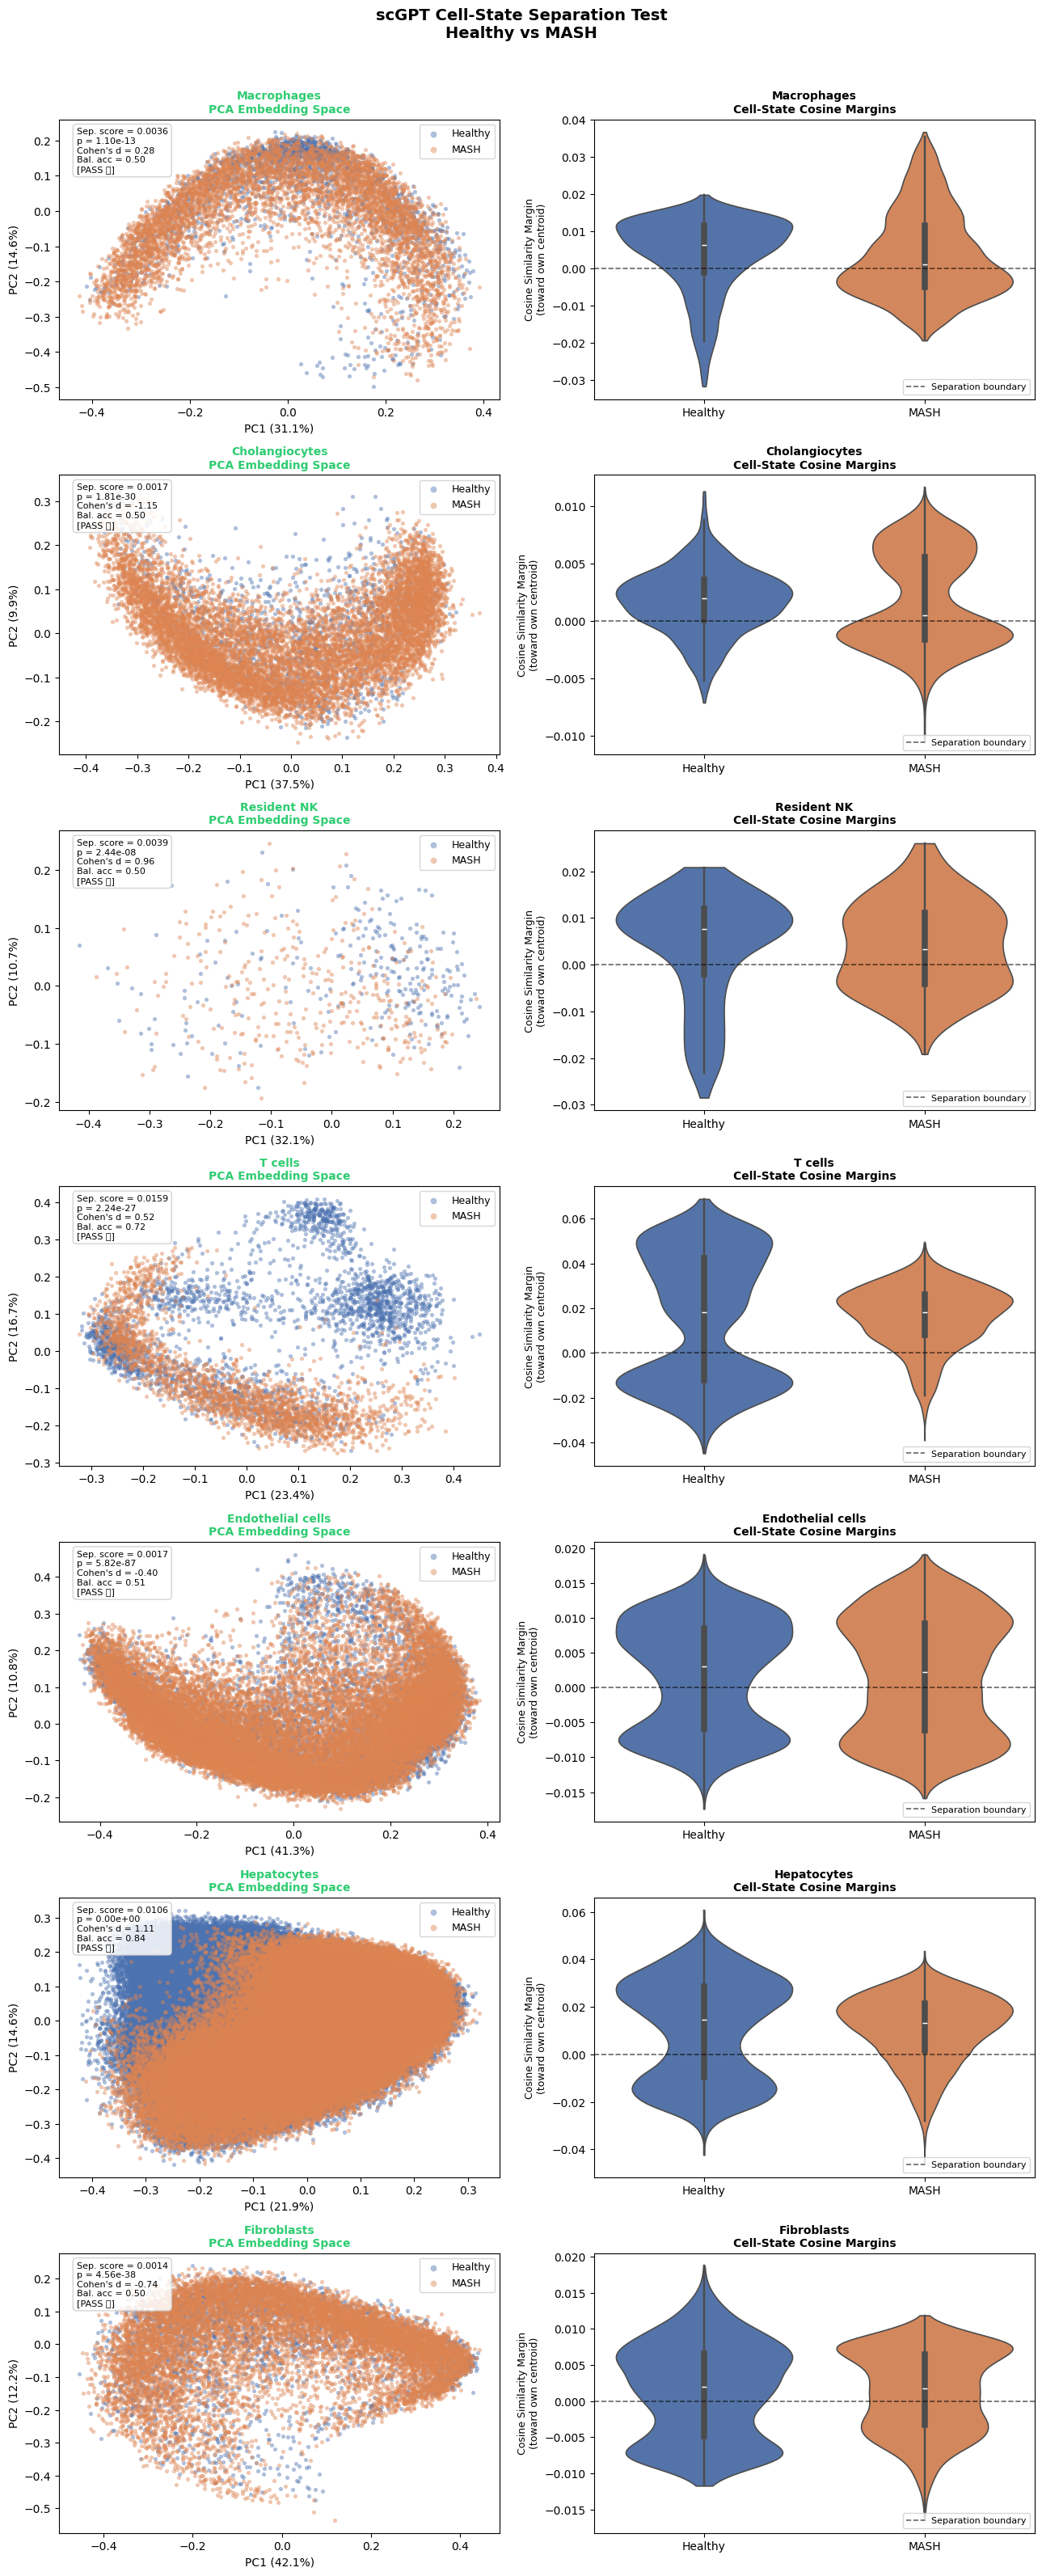

   Saved: /mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_liver/separation_test_figures/separation_per_celltype_Healthy_vs_MASH.pdf

Generating Figure 2: Multi-cell-type summary bar charts...


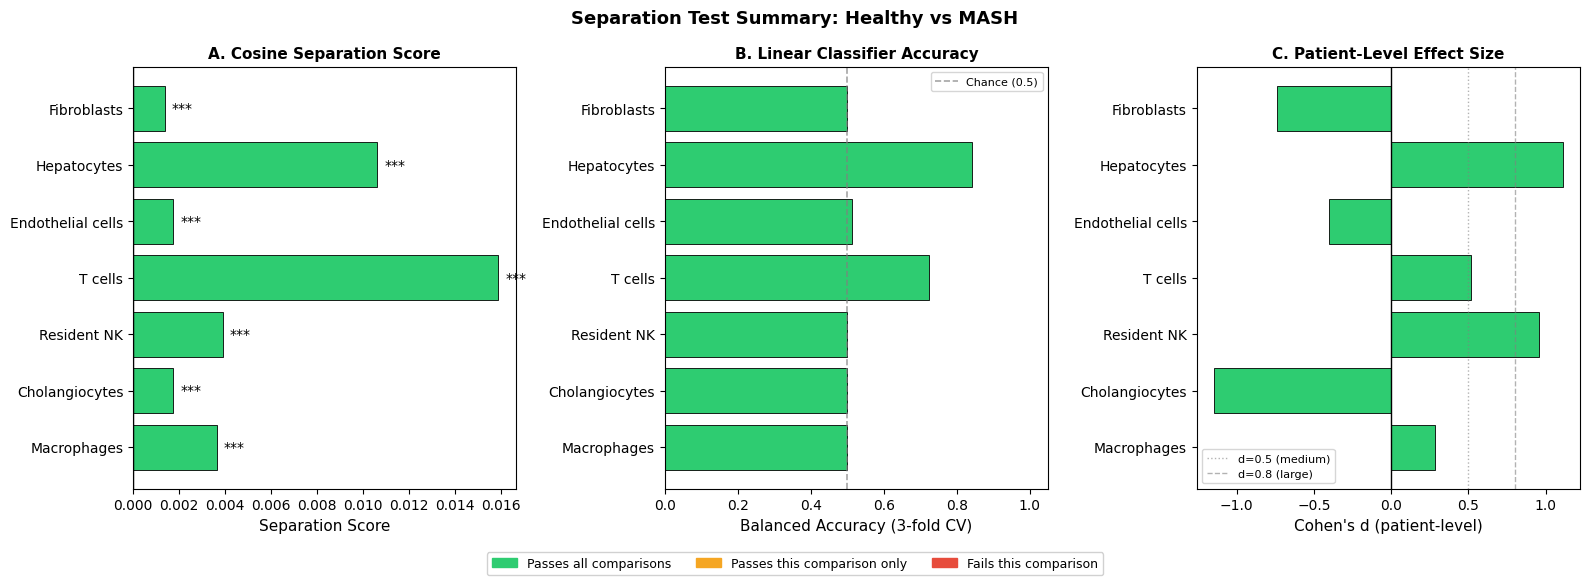

   Saved: /mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_liver/separation_test_figures/separation_summary_Healthy_vs_MASH.pdf

Done. All figures saved to: /mnt/hd1/home/ankitray/scFM/results/scGPT/separation_test_output_celltype_liver/separation_test_figures


In [25]:
"""
Fixed Figure Generation (v2)
=============================
Drop this cell in place of the original "Figures" cell.

Root cause of the original bug
--------------------------------
The figure cell used bare loop variables `embeddings`, `emb_feature_cols`,
and `cell_types_to_test` — all left pointing to the *last* dataset after the
separation-test loop, so only that dataset's cell types produced plots.

v1 fix issue
-------------
v1 concatenated all datasets and fit one global PCA. But embeddings are
generated *per cell type*, so a global PCA is dominated by between-cell-type
variance rather than within-cell-type condition variance — making the scatter
plots misleading.

v2 fix
-------
Fit a *separate* PCA per cell type using only that cell type's embedding rows,
then use those per-cell-type coordinates for plotting. Stats (sep_score,
p_value, cohens_d, margins) come from separation_results as before — those
are already correct across all cell types.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA

# ── Output directory ──────────────────────────────────────────────────────────
SEP_FIG_DIR = os.path.join(OUTPUT_DIR, 'separation_test_figures')
os.makedirs(SEP_FIG_DIR, exist_ok=True)

SIG_GREEN = '#2ecc71'
FAIL_RED  = '#e74c3c'
AMBER     = '#F5A623'

_alt_states  = ALT_STATES if 'ALT_STATES' in dir() and ALT_STATES else []
_all_states  = [CONTROL_LABEL, TARGET_LABEL] + list(_alt_states)
_base_colors = ['#4C72B0', '#DD8452', '#59A14F', '#B07AA1',
                '#E15759', '#76B7B2', '#F28E2B']
PALETTE = {state: _base_colors[i % len(_base_colors)]
           for i, state in enumerate(_all_states)}

_tested_pairs = list(state_pairs)

# ── Meta columns to exclude from feature detection ────────────────────────────
_meta_cols = {'cell_type', 'condition', 'donor', 'cell_id'}

# ─────────────────────────────────────────────────────────────────────────────
# Build a unified lookup:
#   ct_embedding_map[cell_type] = (embeddings_df_for_that_ct, feature_cols)
#
# Each entry in embeddings_dict is one per-cell-type DataFrame. A cell type
# appears in exactly one of them (keyed by the AnnData filename stem).
# We invert the mapping so figure code can look up by cell_type string.
# ─────────────────────────────────────────────────────────────────────────────
ct_embedding_map = {}   # cell_type str → (DataFrame, feature_col_list)

for emb_name, df in embeddings_dict.items():
    feat_cols = [
        c for c in df.columns
        if c not in _meta_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    for ct in df['cell_type'].unique():
        ct_embedding_map[ct] = (df, feat_cols)

all_cell_types_tested = list(separation_results.keys())
print(f"Cell types in separation_results : {len(all_cell_types_tested)}")
print(f"Cell types in ct_embedding_map   : {len(ct_embedding_map)}")

# ─────────────────────────────────────────────────────────────────────────────
# FIT PER-CELL-TYPE PCA
# For each cell type fit PCA on its own embedding rows only, then store the
# 2D coordinates alongside condition labels for plotting.
# ─────────────────────────────────────────────────────────────────────────────
ct_pca_map = {}   # cell_type → {'df': DataFrame with PC1/PC2, 'pca': PCA obj}

for ct in all_cell_types_tested:
    if ct not in ct_embedding_map:
        continue
    df, feat_cols = ct_embedding_map[ct]

    ct_df = df[df['cell_type'] == ct].copy()
    if len(ct_df) < 2:
        continue

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(ct_df[feat_cols].values)
    ct_df['PC1'] = coords[:, 0]
    ct_df['PC2'] = coords[:, 1]

    ct_pca_map[ct] = {'df': ct_df, 'pca': pca}

print(f"PCA fitted for {len(ct_pca_map)} cell types.")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Per-cell-type panels — one figure per comparison
#   n_celltypes rows × 2 columns  (PCA scatter | cosine-margin violin)
# ══════════════════════════════════════════════════════════════════════════════
print("\nGenerating Figure 1: Per-cell-type separation panels...")

for label_a, label_b, comp_name in _tested_pairs:
    pair_palette = {label_a: PALETTE[label_a], label_b: PALETTE[label_b]}

    cts_with_data = [
        ct for ct in all_cell_types_tested
        if comp_name in separation_results.get(ct, {})
        and separation_results[ct][comp_name]['n_ctrl'] > 0
        and separation_results[ct][comp_name]['n_tgt']  > 0
        and ct in ct_pca_map
    ]

    if not cts_with_data:
        print(f"   No cell types with data for [{comp_name}] — skipping.")
        continue

    print(f"   [{comp_name}]: {len(cts_with_data)} cell types with PCA + stats")

    n_cts = len(cts_with_data)
    fig, axes = plt.subplots(n_cts, 2,
                              figsize=(13, 4.5 * n_cts),
                              squeeze=False)
    fig.suptitle(
        f'scGPT Cell-State Separation Test\n{comp_name}',
        fontsize=14, fontweight='bold', y=1.01
    )

    for row_idx, ct in enumerate(cts_with_data):
        res     = separation_results[ct][comp_name]
        pca_obj = ct_pca_map[ct]['pca']
        ct_df   = ct_pca_map[ct]['df']

        # Only plot the two conditions being compared
        plot_df = ct_df[ct_df['condition'].isin([label_a, label_b])]

        passes_all  = ct in passing_celltypes
        title_color = SIG_GREEN if passes_all else FAIL_RED

        # ── Panel A: PCA scatter ──────────────────────────────────────────
        ax = axes[row_idx, 0]
        for cond, color in pair_palette.items():
            m = plot_df['condition'] == cond
            ax.scatter(plot_df.loc[m, 'PC1'], plot_df.loc[m, 'PC2'],
                       c=color, alpha=0.45, s=14, linewidths=0,
                       label=cond, rasterized=True)
        ax.set_xlabel(
            f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
        ax.set_ylabel(
            f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
        ax.set_title(f'{ct}\nPCA Embedding Space',
                     fontsize=10, fontweight='bold', color=title_color)
        ax.legend(fontsize=9, markerscale=1.5, framealpha=0.8)

        d_str      = (f"Cohen's d = {res['cohens_d']:.2f}"
                      if res['cohens_d'] is not None else "Cohen's d = N/A")
        status_str = 'PASS ✅' if res['passes'] else 'FAIL ❌'
        ax.text(0.04, 0.97,
                f"Sep. score = {res['sep_score']:.4f}\n"
                f"p = {res['p_value']:.2e}\n"
                f"{d_str}\n"
                f"Bal. acc = {res['balanced_accuracy']:.2f}\n"
                f"[{status_str}]",
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round,pad=0.4', fc='white',
                          alpha=0.85, ec='#cccccc'))

        # ── Panel B: Cosine-margin violins ────────────────────────────────
        ax2 = axes[row_idx, 1]
        margin_parts = []
        if len(res['ctrl_margins']) > 0:
            margin_parts.append(pd.DataFrame({
                'Cosine Margin': res['ctrl_margins'],
                'Condition': label_a
            }))
        if len(res['tgt_margins']) > 0:
            margin_parts.append(pd.DataFrame({
                'Cosine Margin': res['tgt_margins'],
                'Condition': label_b
            }))
        if margin_parts:
            margin_df = pd.concat(margin_parts, ignore_index=True)
            sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
                           palette=pair_palette, ax=ax2, inner='box',
                           linewidth=1.2, cut=0, saturation=0.85)
            ax2.axhline(0, color='black', lw=1.2, ls='--', alpha=0.6,
                        label='Separation boundary')
            ax2.set_xlabel('', fontsize=10)
            ax2.set_ylabel(
                'Cosine Similarity Margin\n(toward own centroid)', fontsize=9)
            ax2.set_title(f'{ct}\nCell-State Cosine Margins',
                          fontsize=10, fontweight='bold')
            ax2.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    safe_comp = comp_name.replace(' ', '_').replace('/', '_')
    fig1_path = os.path.join(
        SEP_FIG_DIR, f'separation_per_celltype_{safe_comp}.pdf'
    )
    plt.savefig(fig1_path, dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig(fig1_path.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f"   Saved: {fig1_path}")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Multi-cell-type summary bar charts — one figure per comparison
#   3 panels: separation score | balanced accuracy | Cohen's d
# ══════════════════════════════════════════════════════════════════════════════
print("\nGenerating Figure 2: Multi-cell-type summary bar charts...")

def bar_color(ct, comp):
    if not separation_results[ct][comp]['passes']:
        return FAIL_RED
    if ct in passing_celltypes:
        return SIG_GREEN
    return AMBER

for label_a, label_b, comp_name in _tested_pairs:
    cts_for_comp = [
        ct for ct in all_cell_types_tested
        if comp_name in separation_results.get(ct, {})
        and separation_results[ct][comp_name]['n_ctrl'] > 0
        and separation_results[ct][comp_name]['n_tgt']  > 0
    ]

    if len(cts_for_comp) < 2:
        print(f"   Fewer than 2 cell types for [{comp_name}] — skipping.")
        continue

    sep_scores = [separation_results[ct][comp_name]['sep_score']   for ct in cts_for_comp]
    bal_accs   = [separation_results[ct][comp_name]['balanced_accuracy'] for ct in cts_for_comp]
    cohens_ds  = [(separation_results[ct][comp_name]['cohens_d'] or 0.0) for ct in cts_for_comp]
    pvals      = [separation_results[ct][comp_name]['p_value']     for ct in cts_for_comp]
    colors     = [bar_color(ct, comp_name) for ct in cts_for_comp]

    fig2, axes2 = plt.subplots(
        1, 3, figsize=(16, max(4, len(cts_for_comp) * 0.5 + 2))
    )
    fig2.suptitle(
        f'Separation Test Summary: {comp_name}',
        fontsize=13, fontweight='bold'
    )

    ax = axes2[0]
    bars = ax.barh(cts_for_comp, sep_scores, color=colors,
                   edgecolor='black', linewidth=0.6)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Separation Score', fontsize=11)
    ax.set_title('A. Cosine Separation Score', fontsize=11, fontweight='bold')
    max_sep = max(sep_scores) if sep_scores else 1
    for bar, pv in zip(bars, pvals):
        sig = ('***' if pv < 0.001 else '**' if pv < 0.01
               else '*' if pv < 0.05 else 'ns')
        ax.text(bar.get_width() + max_sep * 0.02,
                bar.get_y() + bar.get_height() / 2,
                sig, va='center', fontsize=10)

    ax2b = axes2[1]
    ax2b.barh(cts_for_comp, bal_accs, color=colors,
              edgecolor='black', linewidth=0.6)
    ax2b.axvline(0.5, color='gray', lw=1.2, ls='--', alpha=0.7, label='Chance (0.5)')
    ax2b.set_xlim(0, 1.05)
    ax2b.set_xlabel('Balanced Accuracy (3-fold CV)', fontsize=11)
    ax2b.set_title('B. Linear Classifier Accuracy', fontsize=11, fontweight='bold')
    ax2b.legend(fontsize=8)

    ax3 = axes2[2]
    ax3.barh(cts_for_comp, cohens_ds, color=colors,
             edgecolor='black', linewidth=0.6)
    ax3.axvline(0,   color='black', lw=1)
    ax3.axvline(0.5, color='gray', lw=1,   ls=':',  alpha=0.6, label="d=0.5 (medium)")
    ax3.axvline(0.8, color='gray', lw=1,   ls='--', alpha=0.6, label="d=0.8 (large)")
    ax3.set_xlabel("Cohen's d (patient-level)", fontsize=11)
    ax3.set_title("C. Patient-Level Effect Size", fontsize=11, fontweight='bold')
    ax3.legend(fontsize=8)

    legend_handles = [
        mpatches.Patch(color=SIG_GREEN, label='Passes all comparisons'),
        mpatches.Patch(color=AMBER,     label='Passes this comparison only'),
        mpatches.Patch(color=FAIL_RED,  label='Fails this comparison'),
    ]
    fig2.legend(handles=legend_handles, loc='lower center', ncol=3,
                fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    safe_comp = comp_name.replace(' ', '_').replace('/', '_')
    fig2_path = os.path.join(
        SEP_FIG_DIR, f'separation_summary_{safe_comp}.pdf'
    )
    plt.savefig(fig2_path, dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig(fig2_path.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f"   Saved: {fig2_path}")

print("\nDone. All figures saved to:", SEP_FIG_DIR)

## Candidate Pertubation Gene Set

In [22]:
print(data_dir)

/mnt/hd1/home/ankitray/scFM/data/liver_cell_type_adata_embedded


In [23]:

candidate_genes_path = "/mnt/hd1/home/ankitray/scFM/data/candidate_gene.csv"
MASH_GENES = pd.read_csv(candidate_genes_path, header=None)[0].tolist()

# Deduplicate while preserving order
_seen = set()
_deduped = []
for g in MASH_GENES:
    if g not in _seen:
        _deduped.append(g)
        _seen.add(g)
MASH_GENES = _deduped

print(f"✅ {len(MASH_GENES)} unique literature-curated MASH/liver candidate genes loaded.")
print(f"   (Single shared list — same genes tested across ALL cell types)")

✅ 5620 unique literature-curated MASH/liver candidate genes loaded.
   (Single shared list — same genes tested across ALL cell types)


In [26]:
import os
import numpy as np
import pandas as pd
import torch
import scgpt as scg
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── scGPT ISP config ───────────────────────────────────────────────────────────
SCGPT_MODEL_DIR     = Path("/mnt/hd1/home/ankitray/scFM/scGPT_CP")   # same model dir you used for embeddings
GENE_COL            = "Gene Symbol"             # adata.var column with gene symbols
CONTROL_LABEL       = "Healthy"
TARGET_LABEL        = "MASH"
CONDITION_COL       = "broad_condition"
CELL_TYPE_COL       = "typist_liver_majority_voting"
DONOR_COL           = "patient_id"

MAX_ISP_CELLS_TOTAL     = 500    # control cells per cell type fed into ISP
MIN_CELLS_PER_DONOR_ISP = 5      # donors with fewer cells are excluded
MIN_CELLS_PER_GENE      = 20     # min cells a gene must appear in to be scored
EFFECT_SIZE_THRESHOLD   = 2.5e-4 # minimum |median cosine shift| to be considered
PERTURB_BIN_VALUE       = 0      # bin to set for down-regulation (0 = silenced)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

ISP_OUTPUT_DIR   = "/mnt/hd1/home/ankitray/scFM/results/scGPT/scgpt_isp_output"
STATS_OUTPUT_DIR = "/mnt/hd1/home/ankitray/scFM/results/scGPT/scgpt_isp_stats"
os.makedirs(ISP_OUTPUT_DIR,   exist_ok=True)
os.makedirs(STATS_OUTPUT_DIR, exist_ok=True)

# Passing cell types from your separation test
passing_celltypes = ['Macrophages', 'Cholangiocytes', 'Resident NK', 
                     'T cells', 'Endothelial cells', 'Hepatocytes', 'Fibroblasts']
print(f"✅ Config set. {len(passing_celltypes)} passing cell types.")

Device: cuda
✅ Config set. 7 passing cell types.


In [28]:
import scipy.sparse as sp
for name, adata in adata_dict.items():
    # Sanitise cell type names to match separation test (/ → _)
    adata.obs['cell_type_isp'] = (
        adata.obs[CELL_TYPE_COL].str.replace('/', '_', regex=False)
    )

    # Subset to Healthy control cells only (ISP always starts from control)
    ctrl_mask = adata.obs[CONDITION_COL] == CONTROL_LABEL
    adata_ctrl = adata[ctrl_mask].copy()
    print(f"Control cells available: {adata_ctrl.n_obs:,}")
    print(f"Conditions check: {adata_ctrl.obs[CONDITION_COL].unique().tolist()}")

    # Confirm raw counts are in layers['counts']
    # scGPT binning needs raw integer counts
    if 'counts' in adata_ctrl.layers:
        X_counts = adata_ctrl.layers['counts']
        print("Using layers['counts'] for binning.")
    elif adata_ctrl.raw is not None:
        X_counts = adata_ctrl.raw[:, adata_ctrl.var_names].X
        print("Using adata.raw for binning.")
    else:
        X_counts = adata_ctrl.X
        print("⚠️  Using adata.X — verify these are raw counts.")

    # Dense for easy indexing; use float32 to save memory
    if sp.issparse(X_counts):
        X_counts_dense = np.array(X_counts.todense(), dtype=np.float32)
    else:
        X_counts_dense = np.array(X_counts, dtype=np.float32)

    gene_names = adata_ctrl.var[GENE_COL].values  # gene symbol array aligned to columns
    print(f"Gene matrix shape: {X_counts_dense.shape}")

Control cells available: 1,957
Conditions check: ['Healthy']
Using layers['counts'] for binning.
Gene matrix shape: (1957, 4895)
Control cells available: 1,289
Conditions check: ['Healthy']
Using layers['counts'] for binning.
Gene matrix shape: (1289, 4909)
Control cells available: 250
Conditions check: ['Healthy']
Using layers['counts'] for binning.
Gene matrix shape: (250, 4913)
Control cells available: 2,637
Conditions check: ['Healthy']
Using layers['counts'] for binning.
Gene matrix shape: (2637, 4919)
Control cells available: 7,653
Conditions check: ['Healthy']
Using layers['counts'] for binning.
Gene matrix shape: (7653, 4894)
Control cells available: 163,478
Conditions check: ['Healthy']
Using layers['counts'] for binning.
Gene matrix shape: (163478, 4898)
Control cells available: 2,607
Conditions check: ['Healthy']
Using layers['counts'] for binning.
Gene matrix shape: (2607, 4909)


In [16]:
# scGPT tokenises expression by binning normalised counts.
# Down-regulation ISP = set the gene's bin to PERTURB_BIN_VALUE (0).
# We replicate the same binning scgpt.tasks.embed_data uses internally
# so our perturbation is in the same representation space the model expects.
#
# scGPT uses n_bins=51 by default (bins 0-51). Bin 0 = not expressed.
# We zero out the raw count for the target gene, which after normalisation
# and binning maps to bin 0 — equivalent to "not expressed" / down-regulated.

N_BINS = 51  # scGPT default

def bin_expression(raw_counts_row, n_bins=N_BINS):
    """
    Replicate scGPT's expression binning for a single cell (1D array).
    Returns integer bin values aligned to the same gene axis.
    """
    total = raw_counts_row.sum()
    if total == 0:
        return np.zeros(len(raw_counts_row), dtype=np.int32)
    # Normalise to 10k (same as scGPT default)
    normed = raw_counts_row / total * 1e4
    log1p  = np.log1p(normed)
    # Bin non-zero values into n_bins equal-quantile bins
    nonzero_mask = log1p > 0
    bins = np.zeros(len(log1p), dtype=np.int32)
    if nonzero_mask.sum() > 0:
        vals = log1p[nonzero_mask]
        # scGPT uses rank-based binning: divide into n_bins equal groups
        ranks    = vals.argsort().argsort()  # rank each value
        n_nonzero = len(vals)
        bin_edges = np.linspace(0, n_nonzero, n_bins + 1)
        bin_idx   = np.searchsorted(bin_edges, ranks, side='right').clip(1, n_bins)
        bins[nonzero_mask] = bin_idx
    return bins

# Quick sanity check
_test_bins = bin_expression(X_counts_dense[0])
print(f"Bin range for first cell: {_test_bins.min()} – {_test_bins.max()}")
print(f"Non-zero bins: {((_test_bins > 0).sum())} / {len(_test_bins)}")
print("✅ Binning function ready.")

Bin range for first cell: 0 – 51
Non-zero bins: 149 / 2891
✅ Binning function ready.


In [17]:
def patient_aware_sample_for_isp(obs_df, donor_col,
                                  max_cells_total=MAX_ISP_CELLS_TOTAL,
                                  min_cells_per_donor=MIN_CELLS_PER_DONOR_ISP,
                                  random_state=42):
    """
    Sample cells proportionally across donors, with a minimum per-donor
    threshold. Returns (list_of_obs_index_positions, donor_report_dict).
    obs_df must be the .obs slice for the relevant cell type + condition.
    """
    rng = np.random.default_rng(random_state)
    donor_counts = obs_df[donor_col].value_counts()
    eligible     = donor_counts[donor_counts >= min_cells_per_donor].index.tolist()

    if not eligible:
        # Fall back: take all cells, up to max
        idx    = rng.choice(len(obs_df), size=min(max_cells_total, len(obs_df)),
                            replace=False)
        return idx.tolist(), {"random_fallback": len(idx)}

    # Proportional allocation
    total_eligible = donor_counts[eligible].sum()
    sampled_positions = []
    donor_report      = {}

    for donor in eligible:
        d_mask      = obs_df[donor_col] == donor
        d_positions = np.where(d_mask)[0]
        proportion  = len(d_positions) / total_eligible
        n_take      = max(1, int(round(proportion * max_cells_total)))
        n_take      = min(n_take, len(d_positions))
        chosen      = rng.choice(d_positions, size=n_take, replace=False)
        sampled_positions.extend(chosen.tolist())
        donor_report[donor] = n_take

    # Trim to budget
    if len(sampled_positions) > max_cells_total:
        sampled_positions = rng.choice(
            sampled_positions, size=max_cells_total, replace=False
        ).tolist()

    return sampled_positions, donor_report

print("✅ Patient-aware sampler ready.")

✅ Patient-aware sampler ready.


Debugging chunk Below

In [13]:
GENE_COL= "Gene Symbol"

In [14]:
# Run this once interactively before the ISP loop
test_adata = ad.AnnData(
    X=X_counts_dense[:5],
    obs=adata_ctrl.obs.iloc[:5].copy(),
    var=adata_ctrl.var[[GENE_COL]].copy()
)
test_adata.layers['counts'] = X_counts_dense[:5].copy()

test_emb = scg.tasks.embed_data(
    test_adata,
    SCGPT_MODEL_DIR,
    gene_col=GENE_COL,
    batch_size=64,
    return_new_adata=False,
)
print(test_emb)
print(test_emb.obsm.keys())   # ← see what key it actually stored
print(test_emb.shape)

scGPT - INFO - match 1122/1122 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 1/1 [00:03<00:00,  3.97s/it]

AnnData object with n_obs × n_vars = 5 × 1122
    obs: 'sample name', 'source name', 'organism', 'characteristics: shortfilename', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added abs', 'characteristics: number of cells', 'molecule', 'description', 'sample_class', 'assay_type', 'shortfilename', 'sample_group', 'patient_id', 'biopsy_used_for ', 'sex', 'age', 'weight_kg', 'height_cm', 'reason_for_hospitalization', 'procedure', 'concomitant_medication', 'concomitant_disorders_operations', 'alcohol_intake', 'steatosis', 'fibrosis', 'cardiometabolic_func_needed', 'condition', 'bmi', 'gsm_id', 'alcohol_use', 'dataset', 'n_counts', 'n_genes', 'broad_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_h

In [22]:
GENE_COL = "Gene Symbol"

In [25]:
print(f"NaNs in gene col: {test_adata.var[GENE_COL].isna().sum()}")
print(f"dtype: {test_adata.var[GENE_COL].dtype}")

# See what the NaN rows look like
print(test_adata.var[test_adata.var[GENE_COL].isna()].head(10))
print('-'*10)
print(f"NaNs in gene col: {test_adata.var[GENE_COL].notna().sum()}")
print(f"dtype: {test_adata.var[GENE_COL].dtype}")

# See what the NaN rows look like
print(test_adata.var[test_adata.var[GENE_COL].notna()].head(10))

NaNs in gene col: 0
dtype: object
Empty DataFrame
Columns: [Gene Symbol, id_in_vocab]
Index: []
----------
NaNs in gene col: 1122
dtype: object
           Gene Symbol  id_in_vocab
A2M                A2M            3
ABCA13          ABCA13           52
ABCA9            ABCA9           60
ABCG8            ABCG8           95
AC004069.1  AC004069.1        51089
AC005307.1  AC005307.1          297
AC005838.2  AC005838.2        43188
AC006273.4  AC006273.4          397
AC007879.3  AC007879.3          501
AC016831.5  AC016831.5        45372


In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity as cos_sim_sklearn
# import time

# # embeddings DataFrame and emb_feature_cols must be defined
# # (from your separation test chunks — they hold the baseline scGPT embeddings)

# all_results = []

# print(f"\n⚡ Running scGPT ISP (down-regulation by zeroing expression bin)...")
# print(f"   Perturbation : set gene bin → {PERTURB_BIN_VALUE} (down-regulation)")
# print(f"   Cell types   : {len(passing_celltypes)}")
# print(f"   Candidate genes: {len(MASH_GENES)}")
# print(f"   Control → Target: {CONTROL_LABEL} → {TARGET_LABEL}\n")

# for cell_type in passing_celltypes:
#     t_start = time.time()
#     print(f"\n{'─'*60}")
#     print(f"Cell type: {cell_type}")

#     # ── 1. State centroids from baseline embeddings ────────────────────────
#     ctrl_emb_mask = ((embeddings['cell_type'] == cell_type) &
#                      (embeddings['condition'] == CONTROL_LABEL))
#     tgt_emb_mask  = ((embeddings['cell_type'] == cell_type) &
#                      (embeddings['condition'] == TARGET_LABEL))

#     if ctrl_emb_mask.sum() == 0 or tgt_emb_mask.sum() == 0:
#         print(f"   ⚠️  Missing baseline embeddings — skipping.")
#         continue

#     ctrl_centroid = embeddings.loc[ctrl_emb_mask, emb_feature_cols].values.mean(axis=0)
#     tgt_centroid  = embeddings.loc[tgt_emb_mask,  emb_feature_cols].values.mean(axis=0)

#     # Unit-normalise centroids for cosine shift scoring
#     ctrl_centroid_n = ctrl_centroid / (np.linalg.norm(ctrl_centroid) + 1e-12)
#     tgt_centroid_n  = tgt_centroid  / (np.linalg.norm(tgt_centroid)  + 1e-12)

#     baseline_cos = float(np.dot(ctrl_centroid_n, tgt_centroid_n))
#     print(f"   Baseline cosine similarity (ctrl ↔ target): {baseline_cos:.4f}")

#     # ── 2. Select control cells of this cell type ─────────────────────────
#     ct_ctrl_mask = (
#         (adata_ctrl.obs['cell_type_isp'] == cell_type)
#     )
#     ct_obs = adata_ctrl.obs[ct_ctrl_mask]

#     if len(ct_obs) == 0:
#         print(f"   ⚠️  No control cells found in adata — skipping.")
#         continue

#     print(f"   Control cells available: {len(ct_obs)}")

#     # ── 3. Patient-aware sampling ─────────────────────────────────────────
#     if DONOR_COL in ct_obs.columns:
#         sampled_positions, donor_report = patient_aware_sample_for_isp(
#             ct_obs, donor_col=DONOR_COL
#         )
#         print(f"   Sampled {len(sampled_positions)} cells | donors: {donor_report}")
#     else:
#         rng_fallback  = np.random.default_rng(42)
#         n_take        = min(MAX_ISP_CELLS_TOTAL, len(ct_obs))
#         sampled_positions = rng_fallback.choice(len(ct_obs), n_take,
#                                                 replace=False).tolist()
#         print(f"   ⚠️  No donor column — random sample of {n_take} cells.")

#     # Integer positions within adata_ctrl (not the full adata)
#     ct_ctrl_positions = np.where(ct_ctrl_mask)[0]
#     isp_positions     = [ct_ctrl_positions[i] for i in sampled_positions]

#     # Subset count matrix to ISP cells
#     X_isp = X_counts_dense[isp_positions]          # (n_isp_cells, n_genes)
#     n_isp_cells = len(isp_positions)
#     print(f"   ISP input matrix: {X_isp.shape}")

#     # ── 4. Perturb each candidate gene and collect cosine shifts ──────────
#     gene_shifts = {}   # gene_symbol → array of per-cell cosine shifts

#     for gene in MASH_GENES:
#         # Find gene column index
#         gene_col_matches = np.where(gene_names == gene)[0]
#         if len(gene_col_matches) == 0:
#             continue   # gene not in adata.var
#         gene_idx = gene_col_matches[0]

#         # Check how many ISP cells actually express this gene (count > 0)
#         expressing_mask = X_isp[:, gene_idx] > 0
#         n_expressing    = expressing_mask.sum()

#         if n_expressing < MIN_CELLS_PER_GENE:
#             continue   # too few cells — will be skipped in scoring

#         # ── Perturb: set this gene's raw count to 0 (→ bin 0) ────────────
#         X_perturbed = X_isp.copy()
#         X_perturbed[:, gene_idx] = PERTURB_BIN_VALUE  # zero out = down-regulate

#         # ── Re-embed perturbed cells through scGPT ────────────────────────
#         # Build a temporary AnnData with only ISP cells + perturbed counts
#         import anndata as ad
#         adata_perturbed = ad.AnnData(
#             X=X_perturbed,
#             obs=adata_ctrl.obs.iloc[isp_positions].copy(),
#             var=adata_ctrl.var.copy()
#         )
#         # scGPT embed_data expects the raw counts in .X
#         adata_perturbed.layers['counts'] = X_perturbed.copy()

#         try:
#             adata_emb = scg.tasks.embed_data(
#                 adata_perturbed,
#                 SCGPT_MODEL_DIR,
#                 gene_col=GENE_COL,
#                 batch_size=64,
#                 return_new_adata=True,
#             )
#             perturbed_embs = adata_emb.obsm['X_scGPT']  # (n_cells, n_dims)
#         except Exception as e:
#             print(f"   ⚠️  embed_data failed for {gene}: {e}")
#             continue

#         # ── Cosine shift: per-cell distance toward target centroid ────────
#         # shift_i = cos(perturbed_i, target_centroid) - cos(unperturbed_i, target_centroid)
#         # Positive shift = perturbation moved cell toward MASH state
#         X_unperturbed_emb = embeddings.loc[
#             [adata_ctrl.obs_names[p] for p in isp_positions
#              if adata_ctrl.obs_names[p] in embeddings.index],
#             emb_feature_cols
#         ].values

#         # Align: only score cells present in both
#         shared_idx = [
#             i for i, p in enumerate(isp_positions)
#             if adata_ctrl.obs_names[p] in embeddings.index
#         ]
#         if len(shared_idx) < MIN_CELLS_PER_GENE:
#             continue

#         perturbed_embs_shared   = perturbed_embs[shared_idx]
#         unperturbed_embs_shared = X_unperturbed_emb

#         tgt_vec = tgt_centroid_n.reshape(1, -1)
#         cos_perturbed   = cos_sim_sklearn(perturbed_embs_shared,   tgt_vec).flatten()
#         cos_unperturbed = cos_sim_sklearn(unperturbed_embs_shared, tgt_vec).flatten()

#         shifts = cos_perturbed - cos_unperturbed   # positive = toward MASH
#         gene_shifts[gene] = shifts

#     print(f"   Genes with sufficient data: {len(gene_shifts)}/{len(MASH_GENES)}")

#     # ── 5. Score genes for this cell type ─────────────────────────────────
#     if not gene_shifts:
#         print(f"   ⚠️  No gene data for {cell_type} — skipping.")
#         continue

#     # Random baseline: pool all shifts across all genes to get null distribution
#     all_shifts_pool  = np.concatenate(list(gene_shifts.values()))
#     all_shifts_pool  = all_shifts_pool[np.isfinite(all_shifts_pool)]
#     rng_score        = np.random.default_rng(42)

#     from scipy.stats import mannwhitneyu
#     from statsmodels.stats.multitest import multipletests

#     rows = []
#     for gene, shifts in gene_shifts.items():
#         shifts = shifts[np.isfinite(shifts)]
#         if len(shifts) < MIN_CELLS_PER_GENE:
#             continue

#         median_shift = float(np.median(shifts))
#         mean_shift   = float(np.mean(shifts))
#         n_cells      = len(shifts)

#         # Random baseline sample (same n as this gene)
#         null_sample = rng_score.choice(all_shifts_pool, size=n_cells, replace=True)
#         _, pval = mannwhitneyu(shifts, null_sample, alternative='two-sided')

#         rows.append({
#             'gene_symbol':       gene,
#             'cell_type':         cell_type,
#             'target_state':      TARGET_LABEL,
#             'median_cosine_shift': median_shift,
#             'mean_cosine_shift':  mean_shift,
#             'n_cells':            n_cells,
#             'pval_raw':           pval,
#         })

#     if not rows:
#         continue

#     ct_df = pd.DataFrame(rows)

#     # FDR correction within cell type
#     _, pval_adj, _, _ = multipletests(ct_df['pval_raw'].values, method='fdr_bh')
#     ct_df['pval_adj'] = pval_adj

#     # Significant = FDR < 0.05 AND |median shift| > threshold
#     ct_df['significant'] = (
#         (ct_df['pval_adj'] < 0.05) &
#         (ct_df['median_cosine_shift'].abs() > EFFECT_SIZE_THRESHOLD)
#     )

#     # Sort: top hits first (largest positive shift toward MASH = best hits)
#     ct_df = ct_df.sort_values('median_cosine_shift', ascending=False)

#     all_results.append(ct_df)

#     n_sig = ct_df['significant'].sum()
#     elapsed = (time.time() - t_start) / 60
#     print(f"   ✅ Done ({elapsed:.1f} min) | {n_sig} significant genes")
#     if n_sig > 0:
#         print(ct_df[ct_df['significant']][
#             ['gene_symbol', 'median_cosine_shift', 'pval_adj', 'n_cells']
#         ].head(10).to_string(index=False))

#     # Save per-cell-type results
#     safe_ct  = cell_type.replace(' ', '_').replace('/', '_')
#     ct_path  = os.path.join(ISP_OUTPUT_DIR, f"isp_{safe_ct}.csv")
#     ct_df.to_csv(ct_path, index=False)

# print("\n✅ scGPT ISP complete.")

In [ ]:
# if all_results:
#     results_df = pd.concat(all_results, ignore_index=True)
#     results_df = results_df.dropna(subset=['median_cosine_shift'])

#     full_path = os.path.join(STATS_OUTPUT_DIR, 'scgpt_isp_results_full.csv')
#     results_df.to_csv(full_path, index=False)
#     print(f"Saved full results: {full_path}")
#     print(f"Total rows: {len(results_df)}")
#     print(f"Significant hits: {results_df['significant'].sum()}")

#     print(f"\n{'='*60}")
#     print(f"SUMMARY: {CONTROL_LABEL} → {TARGET_LABEL}")
#     print(f"{'='*60}")

#     for ct in passing_celltypes:
#         ct_sig = results_df[
#             (results_df['cell_type'] == ct) & results_df['significant']
#         ].sort_values('median_cosine_shift', ascending=False)

#         print(f"\n  {ct} ({len(ct_sig)} significant):")
#         if len(ct_sig) > 0:
#             print(ct_sig[['gene_symbol', 'median_cosine_shift',
#                            'pval_adj', 'n_cells']].head(10).to_string(index=False))
#         else:
#             print("    No significant hits.")
# else:
#     print("No ISP results. Check earlier steps.")